<a href="https://colab.research.google.com/github/yawri/ExplainableAI_NLP_LegalCourt/blob/main/ThesisTUM_Yawri_ExplainableAI_ML_NLP_LegalCourt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install shap


In [ ]:
# pip install lime

In [ ]:
ls

sample_data/


In [ ]:
# cd ..

In [ ]:
# import pandas as pd

In [ ]:
import pandas as pd
import os
print("Current Working Directory:", os.getcwd())
import json
import string

import os
print("Contents of current directory:", os.listdir())


Current Working Directory: /content
Contents of current directory: ['.config', 'dev.jsonl', 'test.jsonl', 'train.jsonl', 'sample_data']


In [ ]:
# cat train.jsonl

In [ ]:
# Get the current working directory
current_directory = os.getcwd()
print("Current Working Directory:", current_directory)

Current Working Directory: /content


In [ ]:
import json

train_file_path = "train.jsonl"  # nombre del archivo subido

# Leer y procesar el archivo JSONL
with open(train_file_path, "r") as file:
    train_data = [json.loads(line) for line in file]


In [ ]:
# train_data

**Binary Classification**
La hago antes del preprocessing porque no quiero que al remover lo no alfabético me quede sin los números que necesito para clasificar los artículos

1. **Text Cleaning**:
   - Remove any unnecessary whitespace, extra line breaks, and formatting artifacts. (Pendiente)

 - Convert the text to lowercase to ensure consistent processing (unless case sensitivity is important for your task).



In [ ]:
# train_data[0]

In [ ]:
list(train_data[0].keys())

['case_id',
 'case_no',
 'title',
 'judgment_date',
 'facts',
 'applicants',
 'defendants',
 'allegedly_violated_articles',
 'violated_articles',
 'court_assessment_references',
 'silver_rationales',
 'gold_rationales']

In [ ]:
#for key in train_data:
  #print(key)

In [ ]:
print(type(train_data))
#train_data is of type dict, but the word_tokenize function from NLTK expects a string as input.

<class 'list'>


In [ ]:
train_data[0]['violated_articles'],train_data[0]['allegedly_violated_articles']


(['8'], ['13', '8'])

In [ ]:
facts_list = [case['facts'] for case in train_data]
# facts_list


In [ ]:
# facts_list[0]

In [ ]:
import pandas as pd

df = pd.DataFrame()


df['Facts'] = pd.DataFrame({'Facts': facts_list})
df['Facts']

,Facts
0,[11. At the beginning of the events relevant ...
1,[9. The applicant is the monarch of Liechtens...
2,[9. In June 1949 plots of agricultural land o...
3,"[8. In 1991 Mr Dušan Slobodník, a research wo..."
4,"[9. The applicant is an Italian citizen, born..."
...,...
8995,[5. The applicant was born in 1960 and lives ...
8996,[5. The applicant was born in 1946 and is cur...
8997,"[5. The applicants are Russian nationals who,..."
8998,[8. In all cases the applicants brought civil...


In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 54.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from nltk.tokenize import word_tokenize
import re, time
import spacy
import calendar
from spacy.lang.en import stop_words
stop_words = stop_words.STOP_WORDS
# stop_words.remove("n't")
import string

nlp = spacy.load("en_core_web_sm")
punctuations =  ['\n', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', '', '', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~']


df3 = df['Facts']
facts_cleaned = df3.fillna('').astype(str).apply(lambda x: x.lower())

def find_dates(x):
    full_months = [month for month in calendar.month_name if month]
    short_months = [d[:3] for d in full_months]
    months = '|'.join(short_months + full_months)

    sep = r'[.,]?\s+'               # seperator
    day = r'\d+'
    year = r'\d+'
    day_or_year = r'\d+(?:\w+)?'

    r = re.compile(rf'(?:{day}{sep})?(?:{months}){sep}{day_or_year}(?:{sep}{year})?')
    return r.findall(x)

def stop_words_removal(sentence):
    sentence = nlp(sentence)
    # lemmatizing
    sentence = [ word.lemma_.lower().strip() if word.lemma_ != "-PRON-" else word.lower_ for word in sentence ]
#     print (sentence)
    # removing stop words

#     print (stop_words)
    sentence = [ word for word in sentence if word not in stop_words and word not in punctuations and len(word) > 2]
    return sentence
def clean_it(text):
    t1 = time.time()
#     print (text.split('.')[0])
    text = text.replace(text.split('.')[0],'')
    text = text.replace(",", " ,")
    text = text.replace("n't",' not')
    x = re.findall(r'[\s][A-Z][.]', text)
    for i in x:
        text = text.replace(i, '')
    matches = find_dates(text)
    for m in matches:
        text = text.replace(m, '')
    text = text.replace(',', '')
    # Lowercase text
    text = text.lower()

    # Remove punctuation using spaCy
    doc = nlp(text)
    words = [token.text for token in doc if token.text not in string.punctuation ]

    # Lemmatization using spaCy
    lemmatized_words = [token.lemma_ for token in doc]

    # Join the lemmatized words back into a single string
    text = ' '.join(lemmatized_words)

    text = stop_words_removal(text)
    text = ' '.join(text)
    print (time.time() - t1)
#     print (text)
    return text

#     print (text)
# x =    'a. beginning event relevant application daughter son bear 1986 1988 respectively father x father march voluntarily hospitalise month having diagnose suffer schizophrenia august hospitalise period month account illness 1991 hospitalise week diagnose suffer atypical undefinable psychosis appear social welfare health authority contact family 1989 12 applicant initially cohabit summer 1991 1991 live 1991 1993 x involve custody access dispute concern residence order transfer custody 13 hospitalise 22 april 7 13 account psychosis compulsory care 15 accord medical report date 15 paranoid psychotic 14 accord social welfare authority record discussion place social worker mother mother daughter health condition bad destroy childhood picture wedding photo mother break glass pierce eye appear photo mother tired situation support mental health authority add worried afraid happen admit care place observation view determine place compulsory psychiatric care having initially diagnose suffer psychosis condition compulsory care consider meet remain voluntary care allegedly x allow meet pregnant access far limit order district court base doctor opinion court hold child mental development endanger meeting continue supervision order 1992 16 accord record social welfare authority sign behavioural problem psycho
#  report play doll – vulgar term – perform sexual act break mirror presence repeat mummy break mirror ... note social authority 24 state game play picture draw destructive nature accord note 30 march lately child singe day care nursery immense hatred threaten kill everybody occasion fetch describe unpleasant scene shout hit mother react note long play doll game sexual connotation 17 accord record social welfare authority discussion mother number social mental health care official place mention authority intervene upbringing child protection point view drastic way case far appear connection recent hospitalisation forcibly restaurant furious consequence throw thing example microwave oven end floor unable control 18 follow day child welfare support group consist social health authority agree aim place child home month assistance measure open care section 14 1983 child welfare act lastensuojelulaki barnskyddslag 683/1983 – 1983 act period psychological examination child carry 19 3 social welfare official decide behalf social welfare board perusturvalautakunta grundtrygghetsnämnden place child home period month regard short term support measure pursuant 1983 act applicant consult mother sister order find open care measure practicable accord record meeting practical measure propose participant applicant hear object placing child home 20 opinion 12 request social welfare board doctorsl andr consider time able care mental state necessarily permanently prevent care doctorsl andr work hospital care 1991 period indicate 21 report social welfare authority come child home stay boy undergo total change behaviour characterise anger hatred swear etc tired situation view need hospitalisation visit health centre suggest angry accord statement child home come home 1 play child come tell staff ask 3 year old girl girl reply raise voice shake girl let old girl child child frighten behaviour 22 social welfare official decide 3 place child home inform university hospital local hospital writing worried health baby carry request hospital contact soon arrive hospital particularly time baby delivery express wish health care professional pay special attention relationship mother new bear baby beginning 23 18 district hospital birth day accord hospital record mother stay calm delivery delivery write decision concern emergency care order serve hospital child child ward mother behaviour ward later find somewhat restless completely disorderly hospital record indicate understand situation want leave hospital follow day medication prevent secretion milk prescribe leave hospital 19 follow morning post natal examination mother home start push pram place 24 immediately place emergency care pursuant section 18 1983 act birth child inform decision social worker hospital social director decision behalf social welfare board note mental state unstable stage pregnancy consider baby health endang find plan place baby public care lastly consider baby father guarantee development safety addition social director refer family long stand difficulty illness occasionally uncontrolle emotional reaction traumatic child inability care reluctance accept guidance impossibility responsibility development impossibility provide open care support measure necessary extent applicant hear prior decision 24 applicant notify writing decision new bear baby public care notification fax 25 21 social director place emergency care cite principally reason decision 18 concern 26 applicant appeal emergency care order 27 21 social welfare board note emergency care order prohibit unsupervised access hand number supervise visit restrict board decide continue preparation care 28 meeting hold social worker family centre 21 arrival baby hospital absence applicant mention report plan prohibit mother visit month ground reaction predict example break thing home initial period allow visit baby restriction accompany personal nurse plan implement follow entry appear register 24 june mother come personal nurse want visitor allow time 29 ask come social welfare office .30 a.m. order inform decision 21 social director concern 24 m. biological father notify writing decision 21 notification fax 30 hospitalise voluntarily hospital account psychosis having obtain referral doctor health care centre treat 30 31 23 place family centre visit day 32 beginning leave applicant home having tell social welfare official break relationship want applicant continue relationship 33 15 social welfare board decision normal public care reason similar mention emergency care order paragraph 24 prolong access restriction allow child company personal nurse board essentially consider state health remain unstable subject aggressive uncontrolled emotional mood public care proceeding severe mental ordeal patient regard board believe personal security jeopardise access place supervision regard board fear visit child home long supervise staff interest decision 15 applicant hear express objection care decision envisage 34 15 visit child accompany personal nurse register indicate difficult situation 35 19 family unit family centre 36 20 hospitalise voluntary care open ward hospital suffer psychosis leave hospital follow day 26 place observation view determine place compulsory psychiatric care 30 committed compulsory psychiatric care accord file relative early worried contact hospital order hospital care report disappear home behave unsettled aggressive manner hospitalisation month 37 period 18 june visit child respective child home visit accompany personal nurse hospital contact social welfare authority arrange visit having regard state mental health accord centre register visit twice period 38 accord statement social worker good care hospital 23 later family centre agree stay family centre visit day visit father time 13 time organise christen intention baby father later 39 paternity establish 13 grant joint custody 40 travel expense centre pay social welfare authority centre record deduce succeed create relationship baby learn good care home leave spend mother house later new home 41 social welfare board refer public care order county administrative court lääninoikeus länsrätten confirmation applicant oppose support referral board submit statement social welfare official date accord able care new bear live home psychotic year contact child home time week stay flat attach municipal child home care week subsequently care day week new home board begin investigate possible entrust responsibility help support measure board 42 county administrative court confirm care order concern consider mentally ill applicant conflict result away home beginning illness family problem applicant unable provide adequate care care support provide family sufficiently improve family situation measure expect satisfy care need hearing hold 43 county administrative court confirm care order concern repeat reason forward decision 9 september concern hearing hold 44 appeal supreme administrative court korkein hallinto oikeus högsta förvaltningsdomstolen confirmation public care order concern applicant represent public legal adviser yleinen oikeusavustaja allmänna rättsbiträdet supreme administrative court dismiss appeal date supreme administrative court extend time allow appeal confirmation care order respect 46 appeal care order respect confirm county administrative court supreme administrative court grant cost free proceeding appoint ms suomela representative uphold county administrative court decision 47 decision social welfare board place foster home town 120 km away applicant home join foster parent child social welfare official tell applicant foster parent ’ placement year applicant propose child public care implement home relative 48 meantime christen presence 49 consultation hold child home presence accord record mental health unstable psychiatric treatment expect continue year express hope care future agree stay child home visit week thursday saturday begin visit day accord arrangement agree child home 50 social welfare board prolong access restriction follow note social welfare official appear case record social welfare board … 2 ... addition importance future access question placement public foster care preparation difficult ... 52 discharge hospital 53 social welfare board draw plan concern implementation public care applicant alternative plan allegedly ignore instance child meet maternal grandmother home 54 adoption care plan applicant request relaxation access restriction example permit month 55 2 applicant request inter alia social welfare board draw public care plan aim reunification family 56 social welfare authority organise meeting order revise care plan applicant representative attend meeting 57 social director restrict applicant access child monthly visit foster home place supervision hour social director consider ground public care exist view applicant dissatisfied visit set care plan afford child unlimited right parent create obstacle successful placement applicant appeal 58 county administrative court hold oral hearing concern access restriction impose evidence psychiatrist interview dri.-e know personally comment diagnosis concern mental state indicate tendency react psychotic manner conflict situation drp state state health prevent care child consequently illness reason access restriction reason long exist 59 write expert opinion request social welfare board submit county administrative court drv child psychiatrist express opinion child permanently care foster parent applicant visit time discontinue protect child foster parent accord applicant drv meet child consult psychiatrist proposal 60 county administrative court uphold access restriction issue note witness hear orally willing state opinion regard child development reason inter alia follow ... allow access place month allow contact correspondence ensure child retain knowledge biological parent ground public care later cease exist reunification family possible ... 61 county administrative court dismiss applicant request exemption cost relevant legislation cover dispute concern access restriction court hear applicant assist ms suomela 62 applicant request social welfare board discontinue public care 63 social director allegedly tell applicant child bear place public care accord government social director tell expressly ask possible child bear public care 64 opinion submit social welfare board request drp psychiatrist comment possibility revoke public care order conclude mental state prevent custody child accord drp effort public care discontinue access restriction relax possess psychological resource note inter alia close support care upbringing child addition mother time guardian ad litem ready help care drp add psychiatrist adult stand regard interest child drp ’ opinion base report submit drpo psychologist come conclusion regard ability custody child 65 public legal adviser advise request revocation care order 66 hospitalise 15 24 february april apparently account psychosis 67 social welfare board reject applicant request care order revoke state follow moment health child mother family situation change respect comparison situation 1993 decision child care ... accord drp psychiatrist lot instability emotional life fragility bring year experience diagnosis mental illness need – need long time come – therapeutic support treatment regular medication need order guarantee continue possible manage open care custody child drp precise opinion ability care bring child drp explicitly ask opinion 68 applicant appeal request grant exemption cost afford free legal representation request oral hearing 69 child bear applicant having birth leave hospital evening new bear baby wrap blanket walk barefoot cold weather hospital staff realise happen intervene 70 commit compulsory psychiatric care treat hospital care accord psychiatrist observation suffer paranoid schizophrenia time 71 county administrative court grant applicant exemption cost appoint ms suomela representative case concern appeal social welfare board decision decide hold hearing respect applicant request revocation care order provide party opportunity supplement write observation 72 county administrative court reject applicant appeal hold oral hearing court note inter alia accord medical certificate state health improve emotional life unstable continue need psychotherapy medication addition child bear applicant treat hospital factor cause additional strain militate revocation care order 73 social welfare official revise public care plan propose child meet applicant month neutral premise family advice centre foster parent live applicant object proposal consider entail restriction access child instead request meeting month place residence ask separate write decision concern access request appeal 74 letter social director inform applicant long ground access restriction meeting applicant child authorise hour month premise choose social welfare board inform meeting supervise 75 decision social director confirm long ground access restriction 31 january social welfare board confirm decision applicant appeal 76 regard applicant appeal social welfare board decision 31 january county administrative court consider revise care plan draw entail access restriction later renew decision applicant having properly hear respect access request matter refer social welfare board consideration 77 light county administrative court decision act social director formally restrict applicant access child meeting month meeting place foster home addition foster parent visit applicant child month director consider inter alia important child settle foster family environment grow close contact parent mean change insecurity creation new crisis development process settle start jeopardise child progress necessary situation remain stable secure director decision confirm social welfare board applicant appeal 78 county administrative court reject applicant appeal access restriction confirm 79 social welfare official revise public care plan propose child meet applicant month premise school child place residence applicant present proposal care plan revise far access restriction concern applicant propose child meet supervision month public care plan revise propose social welfare official 80 social director restrict applicant access child monthly visit premise school child place residence access place supervision hour foster parent order present time access social director decision confirm social welfare board applicant appeal decision county administrative court request oral hearing court obtain statement child psychiatrist drp recommend applicant representative social welfare board drp statement include follow observation right access person close primarily examine light psychological growth development health require examination quality permanence durability human relationship psychological growth development place interaction human relationship opinion human relationship examine child point view ... ... conclusion note place child home ... mother psychiatric hospital treatment time total thirteen month live mother month year month long spend year month ... stepfather help look month ... foster parent far look year month interruption ... practice kind relationship biological father ... light note human relationship early childhood owe circumstance non continuous short term change stable continuous relationship foster parent ... relationship relevant important psychological growth development ... bear public care immediately bear stay district hospital short time later reception home small child biological father look week june place foster family ... seven month old far stay foster family year month interruption little 3 year 10 month old light note circumstance significant important relationship foster parent relationship foster parent primary importance psychological growth development ... ... child point view especially naturally foster parent foster family family principle concern family life enshrine united nations convention right child european convention human right apply way biological family point view especially important circumstance biological family live light note arrangement help support foster parent good interest child arrangement place ensure important continuous safe human relationship foster parent ... important psychological growth development safe stable condition provide foster family able form maintain good internalise picture biological parent ... separate circumstance opinion comply decision social welfare board concern right access present unrestricted right access right access extent suggest applicant interest child capable meet emotional need ... arrangement concern right access clearly endanger health development opinion question unrestricted right access evaluate child attain age 12 81 statement drp state opinion psychiatric state preclude custody daughter 82 care plan revise social welfare authority applicant inform time meeting concern revision care plan home visit 15 january representative inform meeting letter send applicant attend meeting representative applicant explicitly hear connection express opinion occasion authority record point view plan 83 county administrative court reject applicant appeal social welfare board decision restrict applicant access right paragraph 80 refuse applicant request oral hearing 84 applicant state reply appeal behalf county administrative court find decision court state person decision direct right duty interest direct effect right appeal court consider board decision concern sible parent right access decision 85 social director restrict applicant consequently young child access monthly visit hour premise school child place residence end 1998 applicant appeal 86 care plan revise accord statement drm drp hospitalise health stable beginning 1995 problem concern care live parent time care recommend drm social welfare authority reduce discontinue control visit applicant home order possibility settle normal life constant supervision authority 88 restriction order extend social director end 2000 visit place supervision premise school child place residence visit place applicant home presence foster parent social director consider inter alia reunification family sight foster family child de facto home applicant access child month correspondence maintain child awareness biological parent close contact applicant endanger child development bring change insecurity create new crisis development applicant appeal decision social welfare board reject appeal uphold social director decision reasoning board quote county administrative court drp 89 accord report draw supervisor attend meeting child applicant period adult meeting play game small play later girl spend time hand applicant little contact accord supervisor description especially early report applicant concentrate 90 visit home weekend 21 supervision 91 applicant appeal social welfare board decision concern right access administrative court county administrative court oral hearing hear hold decision 1 administrative court uphold social welfare board decision 92 social authority review care plan having consult applicant decide child remain foster home accord care plan allow meet t close supervision month alternately applicant home foster parent home meeting applicant home place saturday a.m. sunday 4 p.m. meeting foster parent home sunday a.m. 5 p.m. child allow meet relative freely meeting addition child spend day night applicant christmas week summer school holiday 93 ’ foster mother die'
# import time

# clean_it(x)
facts_cleaned = facts_cleaned.apply(clean_it)
facts_cleaned


Streaming output truncated to the last 5000 lines.
1.8108913898468018
0.08254766464233398
0.38994336128234863
0.3027918338775635
0.32108640670776367
0.06156277656555176
0.08106017112731934
1.4030234813690186
0.19571828842163086
0.17351675033569336
0.22145581245422363
0.16600656509399414
0.7473700046539307
1.2617666721343994
2.673795223236084
1.355102777481079
0.1384565830230713
0.22212600708007812
0.285747766494751
0.23383212089538574
1.343855381011963
0.1461954116821289
0.5653910636901855
0.39910101890563965
0.20211076736450195
0.2809302806854248
0.3812215328216553
0.09543299674987793
0.30237388610839844
1.5210857391357422
0.22346067428588867
0.07825660705566406
3.1699066162109375
0.19475030899047852
0.1986832618713379
0.2702455520629883
0.6419320106506348
0.5339903831481934
0.829948902130127
0.5920941829681396
0.5667092800140381
0.44108080863952637
0.30989766120910645
0.21566295623779297
1.4711575508117676
0.20055127143859863
1.1513869762420654
0.6699562072753906
0.13462209701538086


,Facts
0,beginning event relevant application daughter ...
1,applicant monarch liechtenstein bear 1945 live...
2,june 1949 plot agricultural land applicant fat...
3,1991 dušan slobodník research worker field lit...
4,applicant italian citizen bear 1947 live orist...
...,...
8995,applicant bear 1960 live village karakert arme...
8996,applicant bear 1946 currently detention regens...
8997,applicant russian national material time live ...
8998,case applicant bring civil proceeding russian ...


In [ ]:
# facts_cleaned.to_frame(name='facts').to_excel('temp_op.xlsx', index = False)
# facts_cleaned = pd.read_excel('temp_op.xlsx')

In [ ]:
#creo que esto es una redundancia del cleaning de arriba y puede ser innecesario.

# Data cleaning

def clean_text(text):
    text = text.replace('\nIn', '')  # Remove '\nIn' from the text
    translation_table = str.maketrans('', '', string.digits)
    text = text.translate(translation_table)  # Remove numeric characters
    chars = "'.,![]?$%&\’()“”"
    text = text.translate(str.maketrans('', '', chars))  # Remove specified characters in 'chars'
    return text

facts_cleaned = facts_cleaned.apply(clean_text)
# facts_cleaned = '''

NameError: name 'facts_cleaned' is not defined

In [ ]:
facts_cleaned

,Facts
0,beginning event relevant application daughter ...
1,applicant monarch liechtenstein bear 1945 live...
2,june 1949 plot agricultural land applicant fat...
3,1991 dušan slobodník research worker field lit...
4,applicant italian citizen bear 1947 live orist...
...,...
8995,applicant bear 1960 live village karakert arme...
8996,applicant bear 1946 currently detention regens...
8997,applicant russian national material time live ...
8998,case applicant bring civil proceeding russian ...


In [ ]:
facts_cleaned.shape #Lo vamos a recorrer así.

(9000,)

In [ ]:
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from collections import Counter
import nltk

# Download the 'punkt' tokenizer model in order to use word_tokenize()
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
#Remove stop words
import nltk
nltk.download('stopwords') #descargar stopwords en inglés
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
irrelevant_words = ['application', 'a', 'abandon', 'abandoned', 'cited', 'grey', 'relevant', 'four', 'district', 'court', 'district court', 'town court', 'city', 'regional court', 'proceedings', 'regional', 'judgments', 'copy', 'lastly', 'seized', 'a', 'rights', 'abandoned','respectively', 'source', 'sources', 'social', 'authorities', 'since', 'applicants', 'applicant', 'access', 'administrative', 'concerning', 'according', 'august', 'authorities', 'director', 'having', 'january', 'february', 'march', 'april', 'may', 'june', 'july', 'september', 'october', 'november', 'december', 'between', 'hearing', 'however', 'orders']
 #aqui poner las palabras que no quiero de las que me salieron en el stop words y las pongo con comillas aqui.

In [ ]:
words_to_remove = list(stop_words) + irrelevant_words
# words_to_remove

In [ ]:
# facts_cleaned.info()

In [ ]:
facts_cleaned.shape[0]

9000

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
#Limpiar las stop words y las palabras irrelevantes que las stop words no había removido
from nltk.tokenize import word_tokenize
cleaned_removedstopwords = []
for facts in facts_cleaned:
  word_tokens = word_tokenize(facts)
  remove_stopwords_irrelevant = [w for w in word_tokens if not w.lower() in words_to_remove]
  filtered_words = [w for w in remove_stopwords_irrelevant if len(w) > 3]
  article = ' '.join(filtered_words) #unir todas las palabras para generar el articulo completo.
  cleaned_removedstopwords.append(article) # todos los facts limpios juntos, SIN stop words ni palabras irrelevantes. Si imprimo cleaned_removedstopwords agrego todos los artículos después de que quedaron limpios.
  #el append le agrega palabras en cada iteración al cleaned_removedstopwords
  #print(article)
  #break #para que ejecute una sola instrucción

In [ ]:
# cleaned_removedstopwords[3]

In [ ]:
len(train_data)

9000

In [ ]:
import pandas as pd
#Ahora se hace un DataFrame, porque es más sencillo trabajarlo así.
#Cada línea en mis datos es diferente entre sí, entonces al convertirlo en dataframe me puedo dar cuenta que en cada línea hay un veredicto.
df = pd.DataFrame(columns = ['Facts','Privacy','VA']) #DataFrame siempre tiene que ir en mayuscula por regla de Python
for Case in range(len(train_data)): #case en minuscula no se puede usar como variable porque ya es una palabra reservada de python.
    privacy_related = 0
    for art in train_data[Case]['violated_articles']:
        if art in ['8']:
            privacy_related = 1
            break
    #Concatenar es agregar una línea cada vez que concatene. En las filas le agrego nuevas filas.
    #Porque como toda linea del df es un caso diferente, así cada caso tenga su respectiva línea.
    #el df,pd.DataFrame(...) es para que la info del df se incluya dentro del DataFrame que se crea en el ().
    #{} esto es la sintaxis para crear un nuevo DataFrame, ademas del nombre de columna le pongo el valor de las celdas de la fila, por eso se pone {}
    #ignore_index = True, es para ponerle numero a los indices, sino saldría solo 0 para todos los índices (ID). Necesitamos índices para poder identificar cada caso en específico.

    df = pd.concat([df,pd.DataFrame({'Facts':[cleaned_removedstopwords[Case]],'Privacy':[privacy_related],'VA':[train_data[Case]['violated_articles']]})],ignore_index = True)
    #El df tengo que ponerlo con esta indexación a la altura del for art in... para que imprima los del articulo 8, sino va a imprimir los de los otros artículos.

In [ ]:
df

,Facts,Privacy,VA
0,beginning event daughter bear 1986 1988 father...,1,[8]
1,monarch liechtenstein bear 1945 live vaduz lie...,0,[]
2,1949 plot agricultural land father expropriate...,0,[6]
3,1991 dušan slobodník research worker field lit...,0,[10]
4,italian citizen bear 1947 live oristano italy ...,0,[]
...,...,...,...
8995,bear 1960 live village karakert armenia member...,0,[]
8996,bear 1946 currently detention regensdorf fact ...,0,[]
8997,russian national material time live chechen re...,0,"[5, 2, 13, 3]"
8998,case bring civil proceeding russian general ju...,0,"[P1-1, 6]"


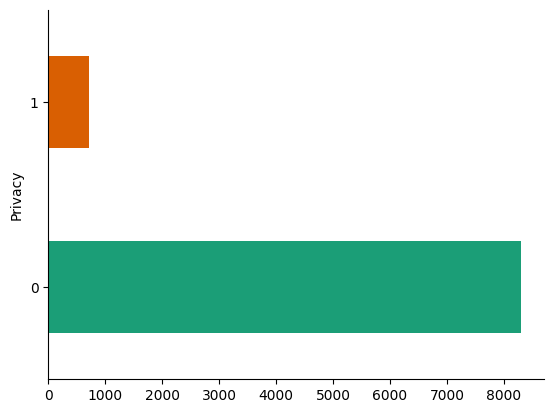

In [ ]:
# @title Privacy

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Privacy').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
print(df.columns)


Index(['Facts', 'Privacy', 'VA'], dtype='object')


In [ ]:
len(df[df["Privacy"]==1]) #df se pone aqui porque ya tengo en df los textos limpios y sin stopwords
#aqui se pone 2 veces df para filtrar del df los casos del mismo df
#Aquí como hay muchos menos casos de privacidad, ya que son 710 con respecto a los 9000, son datos desbalanceados por lo que hay que balancearlos.
#Una forma de balancearlos: No se usan los 9000 sino usar 1420. Al tener 710 de privacidad, usamos solo 710 casos de no privacidad.
print(len(df[df["Privacy"]==1]))

710


In [ ]:
X_train_unbalanced = df["Facts"]
y_train_unbalanced = df["Privacy"]

In [ ]:
'''# [Load and preprocess train_data as before]

# Balancing data (only for training data)
data_1 = df[df["Privacidad"] == 1].head(710).copy()
data_0 = df[df["Privacidad"] == 0].head(710).copy()
balanced_train_data = pd.concat([data_1, data_0], ignore_index=True)

# Feature and Target Selection for Training Data
X_train_balanced = balanced_train_data["Facts"]
y_train_balanced = balanced_train_data["Privacidad"]'''

'# [Load and preprocess train_data as before]\n\n# Balancing data (only for training data)\ndata_1 = df[df["Privacidad"] == 1].head(710).copy()\ndata_0 = df[df["Privacidad"] == 0].head(710).copy()\nbalanced_train_data = pd.concat([data_1, data_0], ignore_index=True)\n\n# Feature and Target Selection for Training Data\nX_train_balanced = balanced_train_data["Facts"]\ny_train_balanced = balanced_train_data["Privacidad"]'

In [ ]:
# Sample a subset of the data for training
# Increase the subset size to 30%
# X_train_subset, y_train_subset = X_train_unbalanced.sample(frac=0.3, random_state=42), y_train_unbalanced.sample(frac=0.3, random_state=42)

In [ ]:
# [Load test_data]
# [Apply the same preprocessing to test_data as applied to train_data]
import json
import pandas as pd
# Load test data
test_file_path = "test.jsonl"
with open(test_file_path, "r") as file:
    test_data = [json.loads(line) for line in file]

# Extract 'Facts' from test data
test_facts_list = [case['facts'] for case in test_data]

# Create DataFrame for test data
test_df = pd.DataFrame({'Facts': test_facts_list})

# Preprocess 'Facts' column in test data (similar to training data)
test_df['Facts'] = test_df['Facts'].fillna('').astype(str).apply(lambda x: x.lower())
test_df['Facts'] = test_df['Facts'].apply(clean_it)  # Use the same clean_text function defined earlier
test_df['Facts'] = test_df['Facts'].apply(clean_text)  # Use the same clean_text function defined earlier

# Tokenization, stop words and irrelevant words removal for test data
test_cleaned = []
for facts in test_df['Facts']:
    word_tokens = word_tokenize(facts)
    remove_stopwords_irrelevant = [w for w in word_tokens if not w.lower() in words_to_remove]
    filtered_words = [w for w in remove_stopwords_irrelevant if len(w) > 2]
    article = ' '.join(filtered_words)
    test_cleaned.append(article)

# Now, test_cleaned contains the preprocessed test data


1.2847373485565186
0.29999804496765137
0.10153770446777344
0.20019006729125977
0.5722928047180176
0.47793149948120117
0.46753597259521484
0.6481773853302002
0.3068859577178955
0.1527118682861328
0.07421493530273438
0.4689362049102783
0.052092552185058594
0.4258909225463867
1.0550956726074219
0.5796530246734619
0.27062010765075684
0.19387245178222656
0.528975248336792
0.4221165180206299
2.116567611694336
1.1894090175628662
0.5199761390686035
0.21398425102233887
0.0968027114868164
0.5987780094146729
0.2881174087524414
0.2546393871307373
0.13104462623596191
0.1915295124053955
0.11273550987243652
0.563868522644043
0.16168570518493652
0.1375560760498047
0.05129122734069824
0.19679999351501465
0.12784719467163086
0.10097861289978027
0.21960783004760742
0.29071593284606934
0.4678173065185547
0.37523388862609863
0.9783046245574951
0.25487446784973145
0.6429071426391602
0.210892915725708
0.1800365447998047
0.9091551303863525
1.061781883239746
0.8997406959533691
0.12479066848754883
0.09527158737

NameError: name 'clean_text' is not defined

In [ ]:
import sys
print(sys.executable)


/usr/bin/python3


In [ ]:
import openpyxl
print("openpyxl is working!")


openpyxl is working!


In [ ]:
print('Samit')

Samit


In [ ]:

# Convert test_cleaned to DataFrame
test_df_processed = pd.DataFrame({'Facts': test_cleaned})
test_df_processed.to_excel('test_clean_temp.xlsx', index =  False)
# test_df_processed = pd.read_excel('test_clean_temp.xlsx')
# Extract features (X) and target (y) for test data
# Assuming 'Privacidad' and 'violated_articles' are columns in your original test_data
X_test = test_df_processed['Facts']
y_test = pd.Series([1 if '8' in case['violated_articles'] else 0 for case in test_data])

# Now, X_test and y_test are ready for the model evaluation


NameError: name 'pd' is not defined

In [ ]:
test_df

,Facts
0,applicant journalist dnno norwegian internet b...
1,applicant bear live odesa time event applican...
2,applicant bear live smědčice november applic...
3,applicant bear live kyiv time event director ...
4,applicant bear live staro oryahovo applicant ...
...,...
995,applicant bear detain lipcani july german p...
996,applicant bear live corjova village formal co...
997,applicant bear live grimăncăuți fact case sub...
998,applicant bear detain orsk late evening decem...


In [ ]:
# Ensure labels are integers
y_train = y_train_unbalanced.astype(int)
y_test = y_test.astype(int)

In [ ]:
import numpy as np
# Check if labels are of correct type and content
print("y_train_unbalanced unique values:", np.unique(y_train))
print("y_test unique values:", np.unique(y_test))

y_train_unbalanced unique values: [0 1]
y_test unique values: [0 1]


In [ ]:
# X_train_unbalanced[0]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2))

# Set a minimum document frequency threshold to exclude overly common terms
tfidf_vectorizer = TfidfVectorizer(min_df=5)  # This excludes terms that appear in fewer than 5 documents
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_unbalanced)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [ ]:
# Check shapes and types of TF-IDF matrices
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)
print("Type of X_train_tfidf:", type(X_train_tfidf))
print("Type of X_test_tfidf:", type(X_test_tfidf))


X_train_tfidf shape: (9000, 14847)
X_test_tfidf shape: (1000, 14847)
Type of X_train_tfidf: <class 'scipy.sparse._csr.csr_matrix'>
Type of X_test_tfidf: <class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

# Select the top k features based on the chi-squared statistic
k_best = SelectKBest(chi2, k=500)  # Adjust k as needed
X_train_tfidf_reduced = k_best.fit_transform(X_train_tfidf, y_train)
X_test_tfidf_reduced = k_best.transform(X_test_tfidf)


-----A partir de aqui le estoy metiendo mi codigo de ThesisTUM_code----

In [ ]:
# Import necessary libraries
import string
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize

In [ ]:
# Apply Truncated SVD for Dimensionality Reduction
svd = TruncatedSVD(n_components=100)  # Adjust the number of components based on your needs
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

In [ ]:
# Convert labels to NumPy arrays
y_train_np = y_train_unbalanced.to_numpy(dtype=int)
y_test_np = y_test.astype(int).to_numpy(dtype=int)

In [ ]:
# Standard Scaling (if necessary)
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_svd)
X_test_scaled = scaler.transform(X_test_svd)

In [ ]:
from lightgbm import LGBMClassifier

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
# Train the LightGBM model
lgb_model = LGBMClassifier()
lgb_model.fit(X_train_tfidf, y_train_np)

[LightGBM] [Info] Number of positive: 4704, number of negative: 4296
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.987546 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 417440
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 6534
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522667 -> initscore=0.090729
[LightGBM] [Info] Start training from score 0.090729


LGBMClassifier()

In [ ]:
# Get the feature importances
importances = lgb_model.feature_importances_

# Get the feature names after TF-IDF transformation
feature_names = tfidf_vectorizer.get_feature_names_out()

# Check the lengths
print("Number of feature names:", len(feature_names))
print("Number of importances:", len(importances))


Number of feature names: 14847
Number of importances: 14847


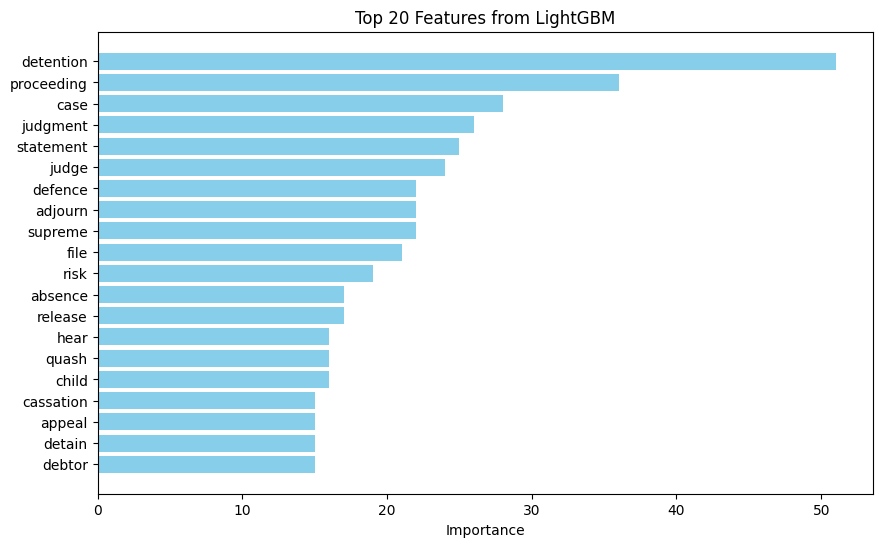

In [ ]:
# Create a DataFrame using all feature names and their importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize the top 20 features
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:20], feature_importance_df['Importance'][:20], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 20 Features from LightGBM')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important features on top
plt.show()


In [ ]:
import pandas as pd

# Assuming you have your TF-IDF matrix named X_train_tfidf
# Get the feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Sum the TF-IDF values across all samples to get the frequency
feature_frequencies = X_train_tfidf.sum(axis=0).A1  # A1 converts it to a 1D array

# Create a DataFrame to hold feature names and their corresponding frequencies
feature_freq_df = pd.DataFrame({'Feature': feature_names, 'Frequency': feature_frequencies})

# Sort the DataFrame by frequency in descending order
sorted_feature_freq_df = feature_freq_df.sort_values(by='Frequency', ascending=False)

# Display the top N features (e.g., top 20)
print(sorted_feature_freq_df.head(20))

# Optionally, if you want to check for specific terms:
a_b_terms = sorted_feature_freq_df[sorted_feature_freq_df['Feature'].str.startswith(('a', 'b'))]
print(a_b_terms)


          Feature   Frequency
663        appeal  457.937874
6596     judgment  356.563861
3065     decision  349.498818
1810         case  335.707378
9862   proceeding  328.527663
10705     request  303.518070
9509       police  302.425362
9982   prosecutor  298.805998
3340    detention  285.609779
2845     criminal  269.910975
8830        order  260.014793
12012       state  252.898784
2106        claim  225.704011
2334      company  214.530408
5577         hold  204.087782
817       article  198.620775
8697       office  197.468140
12370     supreme  197.326065
8702      officer  189.100482
4668         find  187.924280
          Feature   Frequency
663        appeal  457.937874
817       article  198.620775
980     authority  149.528661
1079      bailiff  143.032707
148        action  136.371292
...           ...         ...
981    authorityn    0.077601
911        atomic    0.076578
17    abdulkhakov    0.075765
359      airspace    0.069035
43        abreast    0.054080

[1683 row

In [ ]:
# Train the LightGBM model on the entire dataset (assuming you already did this)
lgb_model = LGBMClassifier()
lgb_model.fit(X_train_tfidf, y_train_np)

# Calculate feature importances using the LightGBM model
importances = lgb_model.feature_importances_


[LightGBM] [Info] Number of positive: 4704, number of negative: 4296
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.477997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 417440
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 6534
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522667 -> initscore=0.090729
[LightGBM] [Info] Start training from score 0.090729


[LightGBM] [Info] Number of positive: 4704, number of negative: 4296
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039323 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 87092
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 497
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522667 -> initscore=0.090729
[LightGBM] [Info] Start training from score 0.090729
LightGBM Accuracy: 0.804
LightGBM Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       701
           1       0.67      0.67      0.67       299

    accuracy                           0.80      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.80      0.80      0.80      1000



/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


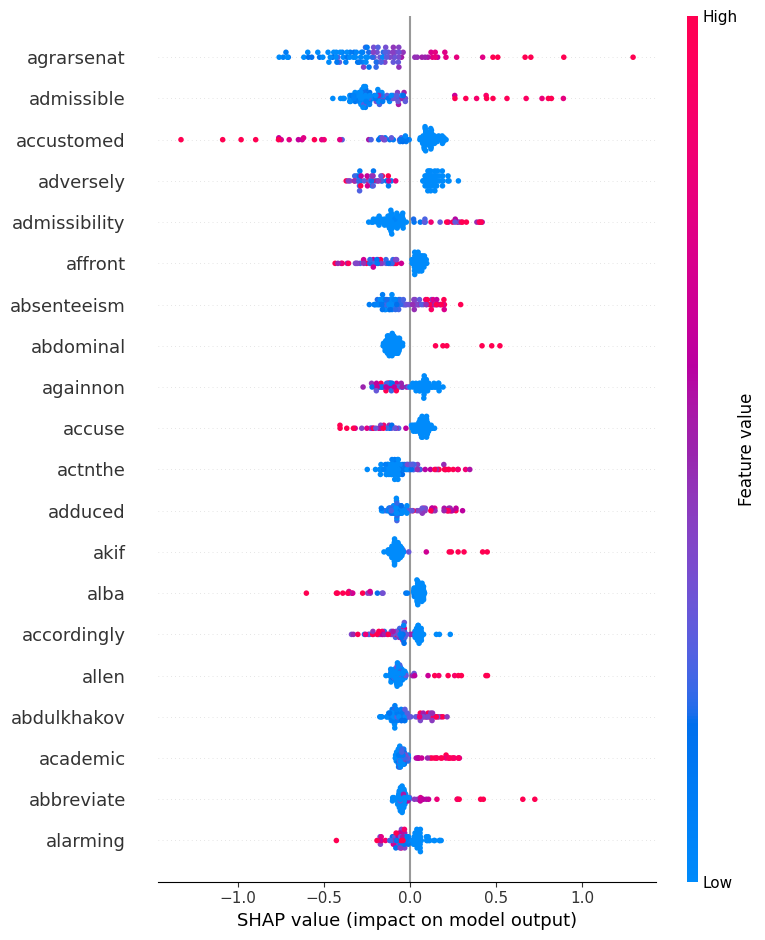

In [ ]:
import shap
from sklearn.feature_selection import SelectKBest, chi2
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Step 1: Reduce Feature Dimensionality
k_best = SelectKBest(chi2, k=500)  # Select the top 500 features
X_train_tfidf_reduced = k_best.fit_transform(X_train_tfidf, y_train_np)
X_test_tfidf_reduced = k_best.transform(X_test_tfidf)

# Step 2: Train the LightGBM Model on the Reduced Feature Set
lgb_model = LGBMClassifier()
lgb_model.fit(X_train_tfidf_reduced, y_train_np)

# Step 3: Make Predictions and Evaluate the Model
y_pred_lgb = lgb_model.predict(X_test_tfidf_reduced)
print("LightGBM Accuracy:", accuracy_score(y_test_np, y_pred_lgb))
print("LightGBM Classification Report:\n", classification_report(y_test_np, y_pred_lgb))

# Step 4: Use a Sample of Data for SHAP
sample_size = 100  # Choose a reasonable sample size
sample_indices = np.random.choice(X_test_tfidf_reduced.shape[0], sample_size, replace=False)
X_test_sample = X_test_tfidf_reduced[sample_indices]

# Ensure the data is dense (for compatibility with SHAP)
X_test_sample_dense = X_test_sample.toarray()

# Step 5: Apply SHAP using TreeExplainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_sample_dense)

# Step 6: Ensure SHAP values are a matrix and plot
if isinstance(shap_values, list):
    # For binary classification, shap_values will be a list with two elements
    shap_values = shap_values[1]  # Choose the SHAP values for class 1

    shap_values = np.array(shap_values)  # Ensure it's a numpy array
if shap_values.ndim == 1:
    shap_values = shap_values.reshape(-1, 1)  # Convert to matrix form if needed

# Step 7: Plot SHAP summary plot for the selected class
shap.summary_plot(shap_values, X_test_sample_dense, feature_names=tfidf_vectorizer.get_feature_names_out())


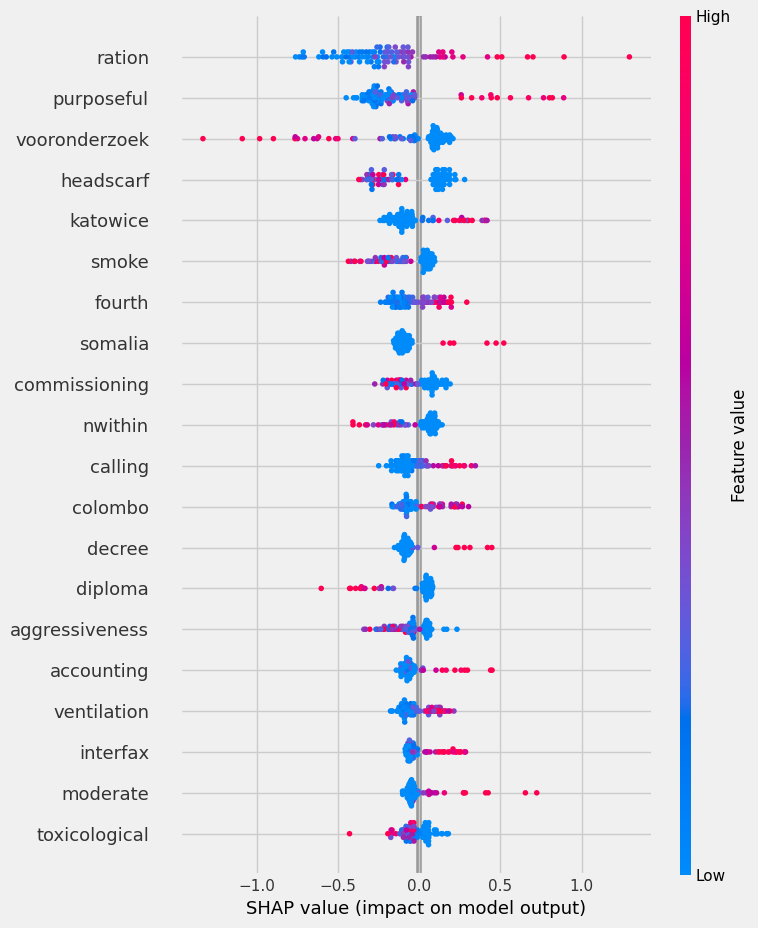

In [ ]:
import numpy as np
import shap
import random

# Assuming you already have your tfidf_vectorizer fitted
original_feature_names = tfidf_vectorizer.get_feature_names_out()

# Shuffle the original feature names
random.shuffle(original_feature_names)

# Plot SHAP summary with shuffled original feature names
shap.summary_plot(shap_values, X_test_sample_dense, feature_names=original_feature_names)


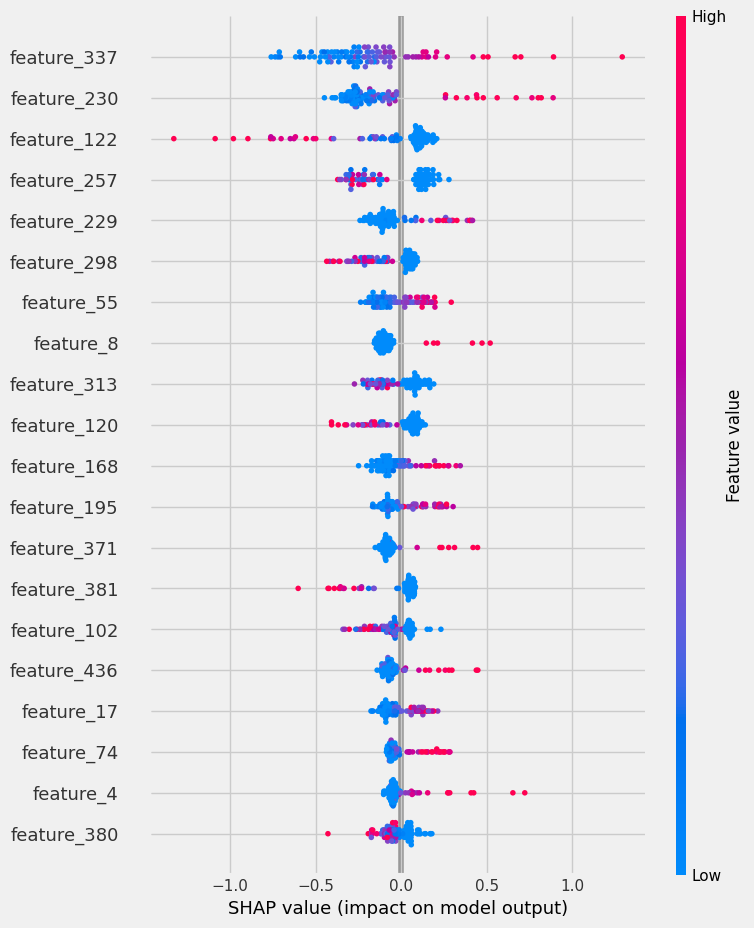

In [ ]:
import numpy as np
import shap
import random

# Generate random feature names of the same length as your original feature names
original_feature_names = tfidf_vectorizer.get_feature_names_out()

# Shuffle or generate random strings
random_feature_names = [f"feature_{i}" for i in range(len(original_feature_names))]  # You can also randomize this

# Alternatively, you can shuffle the original feature names
random.shuffle(original_feature_names)

# Plot SHAP summary with random feature names
shap.summary_plot(shap_values, X_test_sample_dense, feature_names=random_feature_names)


In [ ]:
j=0
for i in tfidf_vectorizer.get_feature_names_out():
  j+=1
  print(i)
  if j==3000:
    break

aachen
abad
abandonment
abaúj
abbreviate
abbreviation
abdoman
abdomen
abdominal
abduct
abducted
abduction
abductionnb
abductor
abdul
abdula
abdulkadir
abdulkhakov
abdullah
abdurrahman
abet
abetting
abeyance
abide
ability
abkhazia
able
abnormal
abnormality
abnormally
aboard
abode
abolish
abolition
abortion
above
abovementione
abovementioned
aboven
abovenon
aboventhe
abrasion
abrasive
abreast
abridge
abridged
abroad
abrogate
abrupt
abruptly
abscess
abscond
absconding
absence
absent
absenteeism
absentia
absolute
absolutely
absolve
absorb
abstain
abstention
abstinence
abstract
absurd
absurdity
abubakar
abundance
abundant
abuse
abuser
abusive
abusively
academic
academy
acar
accede
accelerate
accelerated
acceleration
accent
accept
acceptable
acceptance
accessibility
accessible
accession
accessory
accident
accidental
accidentally
accommodate
accommodation
accompany
accompanying
accompli
accomplice
accomplish
accomplishment
accord
accordance
accordingly
account
accountability
accountable
accou

In [ ]:
Z:# Create a DataFrame using all feature names and their importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Ensure lengths match
print("Number of feature names:", len(feature_names))
print("Number of importances:", len(importances))

print(feature_importance_df.head())


Number of feature names: 14847
Number of importances: 14847
       Feature  Importance
0       aachen           0
1         abad           0
2  abandonment           0
3        abaúj           0
4   abbreviate           0


In [ ]:
print("Shape of shap_values:", shap_values.shape)
# mean_shap_values = np.mean(shap_values, axis=0)
print("Shape of mean_shap_values:", mean_shap_values.shape)
print("Shape of feature_names:", feature_names.shape)



Shape of shap_values: (100, 500)


NameError: name 'mean_shap_values' is not defined

In [ ]:
# Define importance threshold
importance_threshold = 0.01  # Adjust this based on your criteria

# Calculate the mean absolute SHAP values across all samples for each feature
mean_shap_values = np.abs(shap_values).mean(axis=0)

# Create a boolean mask for significant features based on mean SHAP values
important_features_mask = mean_shap_values > importance_threshold

# Get the indices of the selected features based on the mask
important_feature_indices = np.where(important_features_mask)[0] # the [0] is necessary because np.where returns a tuple, and [0] accesses the first element of that tuple, which contains the indices of the True values

# Filter the SHAP values using the mask to select relevant columns
filtered_shap_values = shap_values[:, important_feature_indices]

# Get the corresponding feature names for the selected features
filtered_feature_names = feature_names[important_feature_indices]  # Now this should match

# Create a DataFrame for filtered features and their corresponding mean SHAP values
filtered_feature_importance_df = pd.DataFrame({
    'Feature': filtered_feature_names,
    'Mean SHAP Value': mean_shap_values[important_features_mask]  # Mean SHAP value for the filtered features
})

# Check the filtered DataFrame
print(filtered_feature_importance_df.sort_values(by='Mean SHAP Value', ascending=False).head(20))  # Display top 20 features


In [ ]:
pip install lime


In [ ]:
import shap
from sklearn.feature_selection import SelectKBest, chi2
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

# Step 1: Reduce Feature Dimensionality
k_best = SelectKBest(chi2, k=500)  # Select the top 500 features
X_train_tfidf_reduced = k_best.fit_transform(X_train_tfidf, y_train_np)
X_test_tfidf_reduced = k_best.transform(X_test_tfidf)

# Step 2: Train the LightGBM Model on the Reduced Feature Set
lgb_model = LGBMClassifier()
lgb_model.fit(X_train_tfidf_reduced, y_train_np)

# Step 3: Make Predictions and Evaluate the Model
y_pred_lgb = lgb_model.predict(X_test_tfidf_reduced)
print("LightGBM Accuracy:", accuracy_score(y_test_np, y_pred_lgb))
print("LightGBM Classification Report:\n", classification_report(y_test_np, y_pred_lgb))

# Step 4: Initialize the LIME Explainer
explainer = LimeTabularExplainer(
    training_data=X_train_tfidf_reduced.toarray(),  # Ensure it's dense
    feature_names=tfidf_vectorizer.get_feature_names_out(),
    class_names=['Class 0', 'Class 1'],  # Adjust based on your classes
    mode='classification'
)

# Step 5: Select an instance for explanation
instance_index = 0  # Change this to the index of the instance you want to explain
instance = X_test_tfidf_reduced[instance_index].toarray()  # Ensure it's dense

# Step 6: Generate the explanation
exp = explainer.explain_instance(
    data_row=instance.flatten(),  # Flatten the instance for LIME
    predict_fn=lgb_model.predict_proba,
    num_features=10  # Number of features to show in the explanation
)

# Step 7: Visualize the explanation
exp.show_in_notebook(show_table=True)  # For Jupyter notebooks


In [ ]:
from lightgbm import LGBMClassifier

# Initialize the LGBMClassifier
lgb_model = LGBMClassifier()

# Fit the model
lgb_model.fit(X_train_tfidf, y_train_np)

# Make predictions
y_pred_lgb = lgb_model.predict(X_test_tfidf)

# Evaluate the model
print("LightGBM Accuracy:", accuracy_score(y_test_np, y_pred_lgb))
print("LightGBM Classification Report:\n", classification_report(y_test_np, y_pred_lgb))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the class labels and corresponding precision, recall, f1-scores
classes = ['Class 0', 'Class 1']
precision = [0.92, 0.75]
recall = [0.98, 0.36]
f1_score = [0.95, 0.48]

# Set the width of the bars
bar_width = 0.2

# Set the positions of the bars on the x-axis
r1 = np.arange(len(precision))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Create the figure and axis
plt.figure(figsize=(8, 6))

# Create the bars
plt.bar(r1, precision, color='b', width=bar_width, edgecolor='grey', label='Precision')
plt.bar(r2, recall, color='g', width=bar_width, edgecolor='grey', label='Recall')
plt.bar(r3, f1_score, color='r', width=bar_width, edgecolor='grey', label='F1-Score')

# Add labels
plt.xlabel('Classes', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(precision))], classes)
plt.ylabel('Score')

# Add title and legend
plt.title('Precision, Recall, and F1-Score for LightGBM')
plt.legend()

# Show the plot
plt.show()


In [ ]:
import shap
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Initialize and train the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_tfidf, y_train_np)

# Make predictions to evaluate the model
y_pred_xgb = xgb_model.predict(X_test_tfidf)
print("XGBoost Accuracy:", accuracy_score(y_test_np, y_pred_xgb))
print("XGBoost Classification Report:\n", classification_report(y_test_np, y_pred_xgb))

# Step 2: Reduce Feature Dimensionality
k_best = SelectKBest(chi2, k=500)  # Select the top 500 features
X_train_tfidf_reduced = k_best.fit_transform(X_train_tfidf, y_train_np)
X_test_tfidf_reduced = k_best.transform(X_test_tfidf)

# Step 3: Use a Sample of Data for SHAP to prevent kernel crashes
sample_size = 100  # Adjust this based on memory capacity
sample_indices = np.random.choice(X_test_tfidf_reduced.shape[0], sample_size, replace=False)
X_test_sample = X_test_tfidf_reduced[sample_indices]

# Ensure the data is dense (for compatibility with SHAP)
X_test_sample_dense = X_test_sample.toarray()

# Step 4: Apply SHAP using TreeExplainer for XGBoost
# Instead of shap_values, use explainer.expected_value and explainer.shap_values with correct parameters
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_sample_dense)

# Step 5: Ensure SHAP values are in the right shape and plot the summary plot for the selected class
shap.summary_plot(shap_values.values, X_test_sample_dense, feature_names=tfidf_vectorizer.get_feature_names_out())


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Initialize the XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define the cross-validation strategy
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_results = cross_val_score(xgb_model, X_train_tfidf, y_train_np, cv=kfold, scoring='accuracy')

# Print the cross-validation results
print("Cross-Validation Accuracy Scores:", cv_results)
print("Mean Accuracy:", np.mean(cv_results))
print("Standard Deviation:", np.std(cv_results))

# Fit the model on the full training data
xgb_model.fit(X_train_tfidf, y_train_np)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Evaluate the model
print("XGBoost Accuracy on Test Set:", accuracy_score(y_test_np, y_pred_xgb))
print("XGBoost Classification Report on Test Set:\n", classification_report(y_test_np, y_pred_xgb))


In [ ]:
import shap
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from scipy.sparse import csr_matrix

# Step 1: Feature selection (reduce dimensionality)
k_best = SelectKBest(chi2, k=500)  # Reduce features to top 500
X_train_tfidf_reduced = k_best.fit_transform(X_train_tfidf, y_train_np)
X_test_tfidf_reduced = k_best.transform(X_test_tfidf)

# Step 2: Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Fit the model on the reduced training data
log_reg.fit(X_train_tfidf_reduced, y_train_np)

# Make predictions on the reduced test data
y_pred_lr = log_reg.predict(X_test_tfidf_reduced)
print("Logistic Regression Accuracy:", accuracy_score(y_test_np, y_pred_lr))
print("Logistic Regression Classification Report:\n", classification_report(y_test_np, y_pred_lr))

# Step 3: Use a sample of the data for SHAP (to prevent memory issues)
sample_size = 100  # Adjust sample size as needed
sample_indices = np.random.choice(X_test_tfidf_reduced.shape[0], sample_size, replace=False)
X_test_sample = X_test_tfidf_reduced[sample_indices]

# Step 4: Convert sparse matrix to dense if needed
if isinstance(X_test_sample, csr_matrix):  # Check if it's a sparse matrix
    X_test_sample_dense = X_test_sample.toarray()
else:
    X_test_sample_dense = X_test_sample

# Step 5: Apply SHAP using KernelExplainer for logistic regression
explainer = shap.KernelExplainer(log_reg.predict_proba, X_test_sample_dense)  # Use the predict_proba method
shap_values = explainer.shap_values(X_test_sample_dense)

# Step 6: Plot SHAP summary plot for class 1
shap.summary_plot(shap_values[1], X_test_sample_dense, feature_names=tfidf_vectorizer.get_feature_names_out())


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Fit the model on the training data
log_reg.fit(X_train_tfidf, y_train_np)

# Make predictions on the test data
y_pred_lr = log_reg.predict(X_test_tfidf)

# Evaluate the model
accuracy_lr = accuracy_score(y_test_np, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)
print("Logistic Regression Classification Report:\n", classification_report(y_test_np, y_pred_lr))

In [ ]:
# Build and Train SVM Model with Class Weights
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True)  # Adjust class weights
svm_model.fit(X_train_scaled, y_train_np)

In [ ]:
# Make Predictions on Test Data
y_pred = svm_model.predict(X_test_scaled)

# Evaluate Model
accuracy = accuracy_score(y_test_np, y_pred)
print("Accuracy:", accuracy)

# Display classification report
print("Classification Report:\n", classification_report(y_test_np, y_pred))

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Assuming X_train_tfidf and y_train_np contain your full training data
# and X_test_tfidf and y_test contain your full test data

# Initialize the XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Fit the model on the full training data
xgb_model.fit(X_train_tfidf, y_train_np)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Evaluate the model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the XGBClassifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Fit the model
xgb_model.fit(X_train_tfidf, y_train_np)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Evaluate the model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))

----Hasta aqui es mi codigo de ThesisTUM_code----

In [ ]:
import itertools
def give_comb(param_test, classifier):
    args = list(param_test.values())
    index = 0
    max_f = 0
    for combination in itertools.product(*args):
        temp_dict = {}
        combination = list(combination)
#         print (combination)
    #     combination.extend(['', '','','','',])
    #     df.loc[index] = combination
        index +=1
        for k,v in zip(param_test.keys(), combination):
            temp_dict[k] = v
        print ("Running it for ", str(temp_dict))
        if classifier == 'lgb':
            clf = lgb.LGBMClassifier(**temp_dict)
            clf_cross = fit_and_evaluate(clf)
        elif classifier == 'svm':
            clf = SVC(**temp_dict)
            clf_cross = fit_and_evaluate(clf)
        elif classifier == 'rf':
            clf = RandomForestClassifier(**temp_dict)
            clf_cross = fit_and_evaluate(clf)
        elif classifier ==  'knn':
            clf = KNeighborsClassifier(**temp_dict)
            clf_cross = fit_and_evaluate(clf)
        elif classifier == 'lr':
            clf = LogisticRegression(**temp_dict)
            clf_cross = fit_and_evaluate(clf)
        elif classifier == 'gb':
            clf = XGBClassifier(**temp_dict)
            clf_cross = fit_and_evaluate(clf)
        print (clf_cross)
        if clf_cross > max_f:
            max_f = clf_cross
            best_param = temp_dict
            clf_f = clf
    print (max_f)
    print (best_param)
    return max_f, clf_f, best_param


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')


In [ ]:
# # # Models to Evaluate

# We will compare five different machine learning Classification models:

# 1 - Logistic Regression
# 2 - K-Nearest Neighbors Classification
# 3 - Suport Vector Machine
# 4 - Naive Bayes
# 5 - Random Forest Classification
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5)
# Function to calculate mean absolute error
def cross_val(X_train, y_train, model):
    # Applying k-Fold Cross Validation
    from sklearn.model_selection import cross_val_score
    accuracies = cross_val_score(estimator = model, X = X_train, y = y_train, cv = skf, scoring = "f1")
    print ("f1")
    print (accuracies.mean())
    print ("precision")
    print (cross_val_score(estimator = model, X = X_train, y = y_train, cv = skf, scoring = "precision").mean())
    for p in [0.1, 0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:

        y_train_pred =(model.predict_proba(X_train)[:,1] >= p).astype(bool)
        cm = confusion_matrix(y_train, y_train_pred, labels=model.classes_)
        print ("CM Test")
        print (cm)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)

        disp.plot()

#     for p in [0.1, 0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:

#         y_test_pred =(model.predict_proba(X_test)[:,1] >= p).astype(bool)
#         cm = confusion_matrix(y_test, y_test_pred, labels=model.classes_)
#         print ("CM Test")
#         print (cm)
#         disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)

#         disp.plot()
    return accuracies.mean()
# Takes in a model, trains the model, and evaluates the model on the test set
def fit_and_evaluate(model):

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions and evalute
    model_pred = model.predict(X_test)
    model_cross = cross_val(X_test, y_test, model)

    # Return the performance metric
    return model_cross
X_train = X_train_tfidf
X_test = X_test_tfidf
y_train = y_train.to_numpy(dtype=int)
y_test = y_test.to_numpy(dtype=int)

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


# param_test_svm = {
#     'C': [0.1, 1, 10, 100],  # Add more granularity
#     'kernel': ['linear', 'rbf', 'poly'],  # More kernel options
#     'gamma': ['scale', 'auto']
# }
# svm_cross, clf_svm, best_param_svm = give_comb(param_test_svm, 'svm')

# param_test_rf = param_test1 = {
#     'n_estimators': [200,250, 300,320,350,400,450], 'max_depth': [5,7,9], 'min_samples_split': [5,15,25,45],'min_samples_leaf': [15,20,25,35],  'random_state':[42]}
# rf_cross, clf_rf, best_param_rf = give_comb(param_test_rf, 'rf')

# param_test_knn = {'n_neighbors' : [2,3,4,5], weights = 'uniform',algorithm = 'brute',metric = 'minkowski}

# knn_cross, clf_knn, best_param_knn = give_comb(param_test_knn, 'knn')

# param_test_lr = {'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
#     'C' : np.logspace(-4, 4, 20),
#     'solver' : ['lbfgs','newton-cg','liblinear','sag','saga'],
#     'max_iter' : [100, 1000,2500, 5000]
#     }
# lr_cross, clf_lr, best_param_lr = give_comb(param_test_lr, 'lr')


param_test_gb = dict(
    n_estimators= [100, 500, 1000],
    max_depth= [2, 5, 10, 15],
    learning_rate= [0.01, 0.1, 0.5, 0.9],
    min_child_weight= [1, 2, 5],
#     booster= ['gbtree', 'gblinear'],
#     base_score= [0.25, 0.5, 0.75, 0.99]
)
# param_test_gb = {'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.9, 'min_child_weight': 1}
gb_cross, clf_gb, best_param_gb = give_comb(param_test_gb, 'gb')

param_test_lgb = {'boosting_type':[ 'rf', 'goss','gbdt', 'dart'],
             'n_estimators':[50,100,150,200],
    'num_leaves': [10,30,50,80,100],
             'min_child_samples': [20,40,60,80] ,
             'min_child_weight': [1e-5, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4],
             'subsample': [0.3,0.5,0.7,.9, 1] ,
             'colsample_bytree': [0.3,0.5,0.7,.9, 1],
             'reg_alpha': [0, 1e-1, 1, 2, 5, 7, 10, 50, 100],
             'reg_lambda': [0, 1e-1, 1, 5, 10, 20, 50, 100],
            'max_depth': [2,3,4,5],
            'learning_rate':[0.01, 0.05,0.1,0.15,0.2],
            'scale_pos_weight':[6],
            'objective': ['binary']}
# lgb_cross, clf_lgb, best_param_lgb = give_comb(param_test_gb, 'lgb')

# p_l =


In [ ]:
# Now, to better understand the results, I will show in a graph the model that has the better Cross Validation Score
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')
figsize=(8, 6)

# Dataframe to hold the results
model_comparison = pd.DataFrame({'model': ['Logistic Regression', 'K-NN',
                                            'Random Forest',
                                            'Gradiente Boosting'],
                                 'score': [lr_cross, knn_cross,
                                         rf_cross, gb_cross]})

# Horizontal bar chart of test mae
model_comparison.sort_values('score', ascending = True).plot(x = 'model', y = 'score', kind = 'barh',
                                                           color = 'red', edgecolor = 'black')

# Plot formatting
plt.ylabel(''); plt.yticks(size = 14); plt.xlabel('K-Fold Cross Validation'); plt.xticks(size = 14)
plt.title('Model Comparison on Score', size = 20);

NameError: name 'lr_cross' is not defined

In [ ]:
# # Import necessary libraries
# import string
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import TruncatedSVD
# from sklearn.decomposition import PCA
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from nltk.tokenize import word_tokenize

In [ ]:
# #por el Hyperparametertuning voy a usar un Pipeline con el train para el GridSearchCV
# '''# Step-by-step fitting
# print("Fitting TruncatedSVD...")
# X_train_svd = svd.fit_transform(X_train_tfidf)
# X_test_svd = svd.transform(X_test_tfidf)'''

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# # Define the pipeline
# scaler = StandardScaler(with_mean=False)
# svd = TruncatedSVD(n_components=50)  # Increase the number of components
# svm = SVC(class_weight='balanced', probability=True)

# pipeline = Pipeline([
#     ('scaler', scaler),
#     ('svd', svd),
#     ('svm', svm)
# ])

# # Define the parameter grid for RandomizedSearchCV
# param_distributions = {
#     'svm__C': [0.1, 1, 10, 100],  # Add more granularity
#     'svm__kernel': ['linear', 'rbf', 'poly'],  # More kernel options
#     'svm__gamma': ['scale', 'auto']
# }

In [ ]:
# from sklearn.metrics import accuracy_score, classification_report, make_scorer, f1_score, precision_score

# # Define custom scorers
# f1_scorer = make_scorer(f1_score, pos_label=1)
# precision_scorer = make_scorer(precision_score, pos_label=1)

In [ ]:
# # Use StratifiedKFold to ensure stratified cross-validation
# cv = StratifiedKFold(n_splits=3)

In [ ]:
# # Create RandomizedSearchCV object with custom scoring
# from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# random_search = RandomizedSearchCV(pipeline, param_distributions=param_distributions, n_iter=5, cv=cv, scoring={'f1_score': f1_scorer, 'precision_score': precision_scorer}, refit='f1_score', n_jobs=1, random_state=42)

In [ ]:
# # Fit the model
# random_search.fit(X_train_tfidf, y_train_subset)

# # Show the best parameters
# print("Best parameters:", random_search.best_params_)

In [ ]:
# # Evaluate the model on the test data
# best_model = random_search.best_estimator_
# y_pred = best_model.predict(X_test_tfidf)
# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy on test data:", accuracy)
# print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

In [ ]:
# # Realizar la búsqueda de hiperparámetros con validación cruzada
# grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=1, verbose=2)
# grid_search.fit(X_train_tfidf, y_train_unbalanced)


In [ ]:
# print("Fitting StandardScaler...")
# X_train_scaled = scaler.fit_transform(X_train_svd)
# X_test_scaled = scaler.transform(X_test_svd)


In [ ]:
# print("Fitting SVM...")
# svm.fit(X_train_scaled, y_train_unbalanced)

In [ ]:
# # Make Predictions on Test Data
# y_pred = svm.predict(X_test_scaled)

In [ ]:
# # Evaluate Model
# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy:", accuracy)

# # Display classification report
# print("Classification Report:\n", classification_report(y_test, y_pred))

Hasta aqui llega el Singular Value Decomposition para el SVM. Si quiero intentar hacer fine tuning, puedo hacer lo de los dos codigos sigiuientes:

In [ ]:
# """# Adjust the class weight to give more importance to the minority class
# svm = SVC(kernel='linear', class_weight={0: 1, 1: 5}, probability=True)

# # Step-by-step fitting
# print("Fitting TruncatedSVD...")
# X_train_svd = svd.fit_transform(X_train_tfidf)
# X_test_svd = svd.transform(X_test_tfidf)

# print("Fitting StandardScaler...")
# X_train_scaled = scaler.fit_transform(X_train_svd)
# X_test_scaled = scaler.transform(X_test_svd)

# print("Fitting SVM with adjusted class weights...")
# svm.fit(X_train_scaled, y_train_np)

# # Make Predictions on Test Data
# y_pred = svm.predict(X_test_scaled)

# # Evaluate Model
# accuracy = accuracy_score(y_test_np, y_pred)
# print("Accuracy:", accuracy)

# # Display classification report
# print("Classification Report:\n", classification_report(y_test_np, y_pred))""


In [ ]:
# """from imblearn.over_sampling import SMOTE

# # Apply SMOTE to balance the training data
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train_unbalanced)

# # Apply TruncatedSVD and train SVM
# X_train_svd_resampled = svd.fit_transform(X_train_resampled)
# X_test_svd = svd.transform(X_test_tfidf)

# X_train_scaled_resampled = scaler.fit_transform(X_train_svd_resampled)
# X_test_scaled = scaler.transform(X_test_svd)

# svm = SVC(kernel='linear', class_weight='balanced', probability=True)

# print("Fitting SVM on resampled data...")
# svm.fit(X_train_scaled_resampled, y_train_resampled)

# # Make Predictions on Test Data
# y_pred_resampled = svm.predict(X_test_scaled)

# # Evaluate Model
# accuracy_resampled = accuracy_score(y_test_np, y_pred_resampled)
# print("Accuracy after resampling:", accuracy_resampled)

# # Display classification report
# print("Classification Report after resampling:\n", classification_report(y_test_np, y_pred_resampled))"""


SHAP implementation

In [ ]:
# # SHAP and LIME imports
# import shap
# from lime.lime_tabular import LimeTabularExplainer

# # SHAP explanation
# explainer = shap.Explainer(svm, X_train_scaled)
# shap_values = explainer(X_test_scaled)

# # Plot SHAP values for a single prediction
# shap.plots.waterfall(shap_values[0])

# # Summary plot for all predictions
# shap.summary_plot(shap_values, X_test_scaled, feature_names=tfidf_vectorizer.get_feature_names_out())

# # Map feature indices to names
# feature_names = tfidf_vectorizer.get_feature_names_out()

# # Print the feature names and SHAP values for the first instance
# for i, value in enumerate(shap_values[0].values):
#     feature_index = shap_values[0].data[i]
#     if feature_index < len(feature_names):
#         feature_name = feature_names[int(feature_index)]
#         print(f"Feature {i} (Index: {feature_index}): {feature_name} with SHAP value: {value}")
#     else:
#         print(f"Feature {i} (Index: {feature_index}): Index out of range with SHAP value: {value}")


In [ ]:
# import numpy as np

# # Assuming the TF-IDF vectorizer and SVD components are already defined
# feature_names = tfidf_vectorizer.get_feature_names_out()

# def get_top_terms_for_component(component, feature_names, n=5):
#     top_indices = np.argsort(component)[-n:]
#     top_terms = [feature_names[i] for i in top_indices]
#     return top_terms

# # Extract top contributing terms for each component
# top_terms_per_component = {}
# for i, component in enumerate(components):
#     top_terms = get_top_terms_for_component(component, feature_names)
#     top_terms_per_component[i] = top_terms
#     print(f"Component {i}: {top_terms}")


In [ ]:
# # Create a dictionary for relabeling components with their top terms
# relabel_dict = {}
# for i, terms in top_terms_per_component.items():
#     label = f"Component {i} ({', '.join(terms[:2])})"
#     relabel_dict[f"Component {i}"] = label

# # Ensure all components are included in the relabel_dict
# for i in range(X_test_scaled.shape[1]):
#     if f"Component {i}" not in relabel_dict:
#         relabel_dict[f"Component {i}"] = f"Component {i}"

# # Print the relabel dictionary to verify its content
# print("Relabel dictionary:")
# for key, value in relabel_dict.items():
#     print(f"{key}: {value}")


In [ ]:
# import shap

# # Generate a list of feature names with the new labels
# feature_names_with_labels = [relabel_dict[f"Component {i}"] for i in range(X_test_scaled.shape[1])]

# # Print the final feature names to be used in the SHAP plot
# print("Final feature names with labels:")
# print(feature_names_with_labels)

# # Create a SHAP summary plot with relabeled components
# shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names_with_labels)


In [ ]:
# print(type(shap_values))
# print(shap_values.shape)
# print(shap_values.values.shape)
# print(shap_values.data.shape)
# print(shap_values.base_values.shape)



In [ ]:
# import numpy as np
# import shap
# import matplotlib.pyplot as plt

# # Assuming the SHAP values and TF-IDF vectorizer are already defined
# feature_names = tfidf_vectorizer.get_feature_names_out()

# # Function to get top contributing terms for each component
# def get_top_terms_for_component(component, feature_names, n=5):
#     top_indices = np.argsort(component)[-n:]
#     top_terms = [feature_names[i] for i in top_indices]
#     return top_terms

# # Map and display top terms
# top_terms_per_component = {}
# for i, component in enumerate(components):
#     top_terms = get_top_terms_for_component(component, feature_names)
#     top_terms_per_component[i] = top_terms
#     print(f"Component {i}: {top_terms}")

# # Create a dictionary for relabeling components
# relabel_dict = {}
# for i, terms in top_terms_per_component.items():
#     label = f"Component {i} ({', '.join(terms[:2])})"
#     relabel_dict[f"Component {i}"] = label

# # Ensure all components are included in the relabel_dict
# for i in range(X_test_scaled.shape[1]):
#     if f"Component {i}" not in relabel_dict:
#         relabel_dict[f"Component {i}"] = f"Component {i}"

# # Print the relabel dictionary to verify its content
# print("Relabel dictionary:")
# for key, value in relabel_dict.items():
#     print(f"{key}: {value}")

# # Generate a list of feature names with the new labels
# feature_names_with_labels = [relabel_dict[f"Component {i}"] for i in range(X_test_scaled.shape[1])]

# # Print the final feature names to be used in the SHAP plot
# print("Final feature names with labels:")
# print(feature_names_with_labels)

# # Create a SHAP summary plot with relabeled components
# shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names_with_labels)

# # Generate dependence plots for the top components
# for i in range(5):  # Adjust the range as needed
#     plt.figure()
#     shap.dependence_plot(i, shap_values.values, shap_values.data, feature_names=feature_names_with_labels)
#     plt.show()


In [ ]:
# explained_variance = svd.explained_variance_ratio_
# print("Explained variance ratio per component:")
# print(explained_variance)
# print("Cumulative explained variance:")
# print(np.cumsum(explained_variance))


In [ ]:
# import shap
# import numpy as np

# # Select a subset of the training data as the background dataset
# background = X_train_scaled[np.random.choice(X_train_scaled.shape[0], 100, replace=False)]

# # Initialize the KernelExplainer
# explainer = shap.KernelExplainer(svm.predict, background)

# # Select a subset of the test data for explanation
# subset_size = 100  # Adjust as needed
# X_test_subset = X_test_scaled[:subset_size]

# # Compute SHAP values
# shap_values = explainer.shap_values(X_test_subset)

# # Generate SHAP summary plot
# shap.summary_plot(shap_values, X_test_subset, feature_names=feature_names_with_labels)

# # Generate SHAP dependence plots for the top components
# for i in range(5):  # Adjust the range as needed
#     shap.dependence_plot(i, shap_values, X_test_subset, feature_names=feature_names_with_labels)
#     plt.title(f"SHAP Dependence Plot for Component {i} ({feature_names_with_labels[i]})")
#     plt.show()


In [ ]:
# # LIME explanation
# explainer = LimeTabularExplainer(X_train_scaled, feature_names=tfidf_vectorizer.get_feature_names_out(), class_names=['0', '1'], discretize_continuous=True)
# exp = explainer.explain_instance(X_test_scaled[0], svm.predict_proba, num_features=10)

# # Display the LIME explanation
# exp.show_in_notebook(show_table=True, show_all=False)

**data_0_1 está limpio y sin palabras de stopwords**



In [ ]:
# '''from sklearn.model_selection import GridSearchCV
# from sklearn.svm import SVC

# # Define the parameter grid to search
# param_grid = {
#     'C': [0.1, 1, 10, 100, 1000],  # Regularization parameter
#     'gamma': ['scale', 'auto', 0.01, 0.1, 1, 10, 100],  # Kernel coefficient
#     'kernel': ['linear', 'rbf', 'poly']  # Specifies the kernel type to be used in the algorithm
# }

# # Initialize the SVM model
# svm = SVC(class_weight='balanced')

# # Initialize GridSearchCV
# grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='f1_weighted', verbose=2)

# # Fit GridSearchCV
# grid_search.fit(X_train_tfidf, y_train_np)

# # Get the best estimator
# best_svm = grid_search.best_estimator_

# # Make predictions with the best estimator
# y_pred_best = best_svm.predict(X_test_tfidf)

# # Evaluate the best model
# from sklearn.metrics import classification_report
# print("Best SVM Model Evaluation")
# print(classification_report(y_test_np, y_pred_best))'''


In [ ]:
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report

# # After TF-IDF transformation has been applied to X_train_balanced and X_test:
# # tfidf_vectorizer = TfidfVectorizer()
# # X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_balanced)
# # X_test_tfidf = tfidf_vectorizer.transform(X_test)

# # Convert labels to numpy array
# y_train_np = y_train_unbalanced.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train SVM Model with Class Weights
# svm_model = SVC(kernel='linear', class_weight='balanced',probability=True)  # Adjust class weights
# svm_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions on Test Data
# y_pred = svm_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy = accuracy_score(y_test_np, y_pred)
# print("Accuracy:", accuracy)

# # Display classification report
# print("Classification Report:\n", classification_report(y_test_np, y_pred))


LIME

In [ ]:
# import lime
# import lime.lime_tabular
# # LIME Integration
# # Function to get prediction probabilities
# def predict_proba(texts):
#     texts_tfidf = tfidf_vectorizer.transform(texts)
#     return svm_model.predict_proba(texts_tfidf)

# # Initialize LIME Text Explainer
# explainer = LimeTextExplainer(class_names=['Not Violated', 'Violated'])

# # Select an instance to explain (e.g., the first instance from the test set)
# idx = 0  # Change this index to select a different instance
# text_instance = X_test.iloc[idx]

# # Explain the instance using LIME
# exp = explainer.explain_instance(text_instance, predict_proba, num_features=10)

# # Display the explanation
# exp.show_in_notebook(text=True)

In [ ]:
# # LIME Integration
# # Function to get prediction probabilities
# def predict_proba(texts):
#     texts_tfidf = tfidf_vectorizer.transform(texts)
#     return svm_model.predict_proba(texts_tfidf)

# # Initialize LIME Text Explainer
# explainer = LimeTextExplainer(class_names=['Not Violated', 'Violated'])

# # Select an instance to explain (e.g., the first instance from the test set)
# idx = 0  # Change this index to select a different instance
# text_instance = X_test.iloc[idx]

# # Explain the instance using LIME
# exp = explainer.explain_instance(text_instance, predict_proba, num_features=10)

# # Display the explanation
# exp.show_in_notebook(text=True)

SHAP

In [ ]:
# import shap

# # Reduce the number of features for SHAP by limiting ngram_range
# tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1))  # Using unigrams only
# X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_unbalanced)
# X_test_tfidf = tfidf_vectorizer.transform(X_test)  # Note: Only transform, do not fit

# # Ensure the data is dense if using KernelExplainer
# sample_size = 10  # Adjust this number based on your dataset size and memory capacity
# X_train_dense = X_train_tfidf.toarray()
# X_test_dense = X_test_tfidf.toarray()

# # Use the same dimensions for training and test data
# sample_indices_train = np.random.choice(X_train_dense.shape[0], sample_size, replace=False)
# sample_indices_test = np.random.choice(X_test_dense.shape[0], sample_size, replace=False)
# X_train_sample = X_train_dense[sample_indices_train]
# X_test_sample = X_test_dense[sample_indices_test]

# # SHAP for SVM using KernelExplainer
# explainer_svm = shap.KernelExplainer(svm_model.predict, X_train_sample)
# shap_values_svm = explainer_svm.shap_values(X_test_sample)

# shap.summary_plot(shap_values_svm, X_test_sample, feature_names=tfidf_vectorizer.get_feature_names_out())


In [ ]:
# import shap
# import scipy.sparse
# import numpy as np

# # Reduce the number of features for SHAP by limiting ngram_range
# tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1))  # Using unigrams only
# X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_unbalanced)
# X_test_tfidf = tfidf_vectorizer.transform(X_test)  # Note: Only transform, do not fit

# # Ensure the data is dense if using KernelExplainer
# sample_size = 10  # Adjust this number based on your dataset size and memory capacity
# X_train_dense = X_train_tfidf[:sample_size].toarray()
# X_test_dense = X_test_tfidf[:sample_size].toarray()

# # Randomly sample 10 features if the number of features is too large
# num_features = 10
# if X_train_dense.shape[1] > num_features:
#     feature_indices = np.random.choice(X_train_dense.shape[1], num_features, replace=False)
#     X_train_dense = X_train_dense[:, feature_indices]
#     X_test_dense = X_test_dense[:, feature_indices]
#     feature_names = tfidf_vectorizer.get_feature_names_out()[feature_indices]
# else:
#     feature_names = tfidf_vectorizer.get_feature_names_out()

# # Use a simpler model or part of the model if applicable
# # For example, if SVM with linear kernel:
# from sklearn.linear_model import LogisticRegression
# simple_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
# simple_model.fit(X_train_dense, y_train_np[:sample_size])

# # SHAP for the simpler model using KernelExplainer
# explainer_simple = shap.KernelExplainer(simple_model.predict, X_train_dense)
# shap_values_simple = explainer_simple.shap_values(X_test_dense)

# shap.summary_plot(shap_values_simple, X_test_dense, feature_names=feature_names)


In [ ]:
# # SHAP for SVM (using a small sample to start)
# sample_size = 10  # Adjust this number based on your dataset size and memory capacity
# explainer_svm = shap.Explainer(svm_model, X_train_tfidf[:sample_size])
# shap_values_svm = explainer_svm(X_test_tfidf[:sample_size])

# shap.summary_plot(shap_values_svm, X_test_tfidf[:sample_size], feature_names=tfidf_vectorizer.get_feature_names_out())

In [ ]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Generate the confusion matrix
# conf_matrix = confusion_matrix(y_test_np, y_pred)

# # Create a heatmap to visualize the confusion matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
# plt.xlabel("Predicted Labels")
# plt.ylabel("True Labels")
# plt.title("Confusion Matrix")
# plt.show()


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, accuracy_score

# # Initialize the Random Forest Classifier
# # Note: You can adjust n_estimators (number of trees) and other parameters as needed
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# # Fit the model on the training data
# rf_model.fit(X_train_tfidf, y_train_np)

# # Make predictions on the test data
# y_pred_rf = rf_model.predict(X_test_tfidf)

# # Evaluate the model
# accuracy_rf = accuracy_score(y_test_np, y_pred_rf)
# print("Random Forest Accuracy:", accuracy_rf)
# print("Random Forest Classification Report:\n", classification_report(y_test_np, y_pred_rf))


In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, accuracy_score

# # Initialize the Logistic Regression model
# log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# # Fit the model on the training data
# log_reg.fit(X_train_tfidf, y_train_np)

# # Make predictions on the test data
# y_pred_lr = log_reg.predict(X_test_tfidf)

# # Evaluate the model
# accuracy_lr = accuracy_score(y_test_np, y_pred_lr)
# print("Logistic Regression Accuracy:", accuracy_lr)
# print("Logistic Regression Classification Report:\n", classification_report(y_test_np, y_pred_lr))


In [ ]:
# import shap


# # After TF-IDF transformation has been applied to X_train_balanced and X_test:
# # tfidf_vectorizer = TfidfVectorizer()
# # X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_balanced)
# # X_test_tfidf = tfidf_vectorizer.transform(X_test)

# # Convert labels to numpy array
# y_train_np = y_train_unbalanced.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train SVM Model with Class Weights
# svm_model = SVC(kernel='linear', class_weight='balanced', probability=True)  # Adjust class weights and enable probability
# svm_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions on Test Data
# y_pred = svm_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy = accuracy_score(y_test_np, y_pred)
# print("Accuracy:", accuracy)

# # Display classification report
# print("Classification Report:\n", classification_report(y_test_np, y_pred))

# # SHAP for SVM Model
# explainer_svm = shap.Explainer(svm_model, X_train_tfidf)
# shap_values_svm = explainer_svm(X_test_tfidf)

# shap.summary_plot(shap_values_svm, X_test_tfidf, feature_names=tfidf_vectorizer.get_feature_names_out())

# # Random Forest Model
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
# rf_model.fit(X_train_tfidf, y_train_np)
# y_pred_rf = rf_model.predict(X_test_tfidf)
# accuracy_rf = accuracy_score(y_test_np, y_pred_rf)
# print("Random Forest Accuracy:", accuracy_rf)
# print("Random Forest Classification Report:\n", classification_report(y_test_np, y_pred_rf))

# # SHAP for Random Forest Model
# explainer_rf = shap.Explainer(rf_model, X_train_tfidf)
# shap_values_rf = explainer_rf(X_test_tfidf)
# shap.summary_plot(shap_values_rf, X_test_tfidf, feature_names=tfidf_vectorizer.get_feature_names_out())

# # Logistic Regression Model
# log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
# log_reg.fit(X_train_tfidf, y_train_np)
# y_pred_lr = log_reg.predict(X_test_tfidf)
# accuracy_lr = accuracy_score(y_test_np, y_pred_lr)
# print("Logistic Regression Accuracy:", accuracy_lr)
# print("Logistic Regression Classification Report:\n", classification_report(y_test_np, y_pred_lr))

# # SHAP for Logistic Regression Model
# explainer_lr = shap.Explainer(log_reg, X_train_tfidf)
# shap_values_lr = explainer_lr(X_test_tfidf)
# shap.summary_plot(shap_values_lr, X_test_tfidf, feature_names=tfidf_vectorizer.get_feature_names_out())


In [ ]:
# from sklearn.naive_bayes import GaussianNB
# from sklearn.metrics import classification_report, accuracy_score

# # Check the size of the data
# print("Shape of X_train_tfidf:", X_train_tfidf.shape)
# print("Shape of X_test_tfidf:", X_test_tfidf.shape)

# # Use a subset of the data if it's too large
# subset_size = 10000  # Adjust this number based on your system's memory
# if X_train_tfidf.shape[0] > subset_size:
#     X_train_dense = X_train_tfidf[:subset_size].toarray()
#     y_train_np_subset = y_train_np[:subset_size]
# else:
#     X_train_dense = X_train_tfidf.toarray()
#     y_train_np_subset = y_train_np

# if X_test_tfidf.shape[0] > subset_size:
#     X_test_dense = X_test_tfidf[:subset_size].toarray()
#     y_test_np_subset = y_test_np[:subset_size]
# else:
#     X_test_dense = X_test_tfidf.toarray()
#     y_test_np_subset = y_test_np

# # Initialize the Gaussian Naive Bayes model
# gnb = GaussianNB()

# # Fit the model on the training data
# gnb.fit(X_train_dense, y_train_np_subset)

# # Make predictions on the test data
# y_pred_gnb = gnb.predict(X_test_dense)

# # Evaluate the model
# accuracy_gnb = accuracy_score(y_test_np_subset, y_pred_gnb)
# print("Naive Bayes Accuracy:", accuracy_gnb)
# print("Naive Bayes Classification Report:\n", classification_report(y_test_np_subset, y_pred_gnb))


In [ ]:
# from sklearn.naive_bayes import GaussianNB
# from sklearn.metrics import classification_report, accuracy_score

# # Convert sparse matrix to dense for GaussianNB
# X_train_dense = X_train_tfidf.toarray()
# X_test_dense = X_test_tfidf.toarray()

# # Initialize the Gaussian Naive Bayes model
# gnb = GaussianNB()

# # Fit the model on the training data
# gnb.fit(X_train_dense, y_train_np)

# # Make predictions on the test data
# y_pred_gnb = gnb.predict(X_test_dense)

# # Evaluate the model
# accuracy_gnb = accuracy_score(y_test_np, y_pred_gnb)
# print("Naive Bayes Accuracy:", accuracy_gnb)
# print("Naive Bayes Classification Report:\n", classification_report(y_test_np, y_pred_gnb))


In [ ]:

# # Get the feature names from the TF-IDF vectorizer
# feature_names = tfidf_vectorizer.get_feature_names_out()

# # Get the coefficients from the trained SVM model
# # For a linear kernel, these can be interpreted as feature importance
# coefs = svm_model.coef_.toarray().flatten()

# # Create a DataFrame for easy analysis
# import pandas as pd
# feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})

# # Sort the features by their absolute coefficients to see the most influential ones
# # Using absolute value as importance can be both positive and negative
# top_features = feature_importance.reindex(abs(coefs).argsort()[::-1])

# print(top_features.head(30))  # Adjust the number to see more/less features


In [ ]:
# balanced_train_data

In [ ]:
# X_train_balanced

In [ ]:
# import numpy as np
# from lightgbm import LGBMClassifier
# from sklearn.metrics import classification_report, accuracy_score

# # Convert y_train_balanced to a NumPy array of integers
# y_train_balanced_np = np.array(y_train_balanced, dtype=int)

# # Initialize the LGBMClassifier
# lgb_model = LGBMClassifier()

# # Fit the model
# lgb_model.fit(X_train_tfidf, y_train_balanced_np)

# # Make predictions
# y_pred_lgb = lgb_model.predict(X_test_tfidf)

# # Evaluate the model
# print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
# print("LightGBM Classification Report:\n", classification_report(y_test, y_pred_lgb))


In [ ]:
# from xgboost import XGBClassifier
# from sklearn.metrics import classification_report, accuracy_score

# # Initialize the XGBClassifier
# xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# # Fit the model
# xgb_model.fit(X_train_tfidf, y_train_balanced)

# # Make predictions
# y_pred_xgb = xgb_model.predict(X_test_tfidf)

# # Evaluate the model
# print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
# print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))


In [ ]:
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, accuracy_score

# # Convert y_train_balanced to a NumPy array
# y_train_balanced_np = np.array(y_train_balanced, dtype=int)

# # Build and Train Random Forest Model
# rf_model = RandomForestClassifier(random_state=42, n_estimators=100)  # n_estimators can be tuned
# rf_model.fit(X_train_tfidf, y_train_balanced_np)

# # Make Predictions on Test Data
# y_pred_rf = rf_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy_rf = accuracy_score(y_test, y_pred_rf)
# print("Random Forest Accuracy:", accuracy_rf)
# print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


In [ ]:
# from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# # Calculate F1-score, precision, and recall
# f1 = f1_score(y_test, y_pred_rf)
# precision = precision_score(y_test, y_pred_rf)
# recall = recall_score(y_test, y_pred_rf)

# print(f"F1-score: {f1}")
# print(f"Precision: {precision}")
# print(f"Recall: {recall}")

# # For AUC-ROC, you need the prediction probabilities for the positive class
# y_pred_proba_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]
# roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

# print(f"AUC-ROC: {roc_auc}")


In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report

# # Define parameter range for GridSearchCV
# param_grid = {'C': [0.1, 1, 10, 100],
#               'gamma': [1, 0.1, 0.01, 0.001],
#               'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}

# # Create a GridSearchCV object
# grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)

# # Fit the model for grid search
# grid.fit(X_train_tfidf, y_train_np)

# # Print best parameters found by GridSearchCV
# print("Best Parameters:", grid.best_params_)

# # Use the best parameters to define the final SVM model
# best_params = grid.best_params_
# svm_model = SVC(kernel=best_params['kernel'], C=best_params['C'], gamma=best_params['gamma'])
# svm_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions on Test Data
# y_pred = svm_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy = accuracy_score(y_test_np, y_pred)
# print("Accuracy:", accuracy)
# print("Classification Report:\n", classification_report(y_test_np, y_pred))


In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report

# # Ensure TF-IDF transformation has been applied to X_train_balanced and X_test

# # Convert labels to numpy array
# y_train_np = y_train_balanced.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train Logistic Regression Model
# logreg_model = LogisticRegression(random_state=42)
# logreg_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions on Test Data
# y_pred_logreg = logreg_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy_logreg = accuracy_score(y_test_np, y_pred_logreg)
# print("Logistic Regression Accuracy:", accuracy_logreg)

# # Display classification report for Logistic Regression
# print("Logistic Regression Classification Report:\n", classification_report(y_test_np, y_pred_logreg))


In [ ]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report

# # Ensure TF-IDF transformation has been applied to X_train_balanced and X_test

# # Convert labels to numpy array
# y_train_np = y_train_balanced.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train KNN Model
# knn_model = KNeighborsClassifier(n_neighbors=5)  # Adjust the number of neighbors if needed
# knn_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions on Test Data
# y_pred_knn = knn_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy_knn = accuracy_score(y_test_np, y_pred_knn)
# print("KNN Accuracy:", accuracy_knn)

# # Display classification report for KNN
# print("KNN Classification Report:\n", classification_report(y_test_np, y_pred_knn))


In [ ]:
# # Convert labels to numpy array and specify dtype
# y_train_np = y_train.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train SVM Model
# svm_model = SVC(kernel='linear')
# svm_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions
# y_pred = svm_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy = accuracy_score(y_test_np, y_pred)
# print("Accuracy:", accuracy)

# # Display classification report
# print("Classification Report:\n", classification_report(y_test_np, y_pred))

**Train-Test split and TF-IDF**

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report

# # Feature and Target Selection
# X = data_0_1["Facts"]
# y = data_0_1["Privacidad"]

# # Train-Test Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Vectorize Text Data using TF-IDF
# tfidf_vectorizer = TfidfVectorizer()
# X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
# import numpy as np

# # Convert y_train_balanced to a NumPy array if it's not already
# if not isinstance(y_train_balanced, np.ndarray):
#     y_train_balanced = y_train_balanced.to_numpy(dtype=int)

# # Check the shape of y_train_balanced
# print(y_train_balanced.shape)


In [ ]:
# # Check the type of X_train_tfidf
# print(type(X_train_tfidf))

# # Check the shape of X_train_tfidf
# print(X_train_tfidf.shape)


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, accuracy_score

# # Ensure TF-IDF transformation has been applied to X_train_balanced and X_test
# # X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_balanced)
# # X_test_tfidf = tfidf_vectorizer.transform(X_test)

# # Build and Train Random Forest Model
# rf_model = RandomForestClassifier(random_state=42)
# rf_model.fit(X_train_tfidf, y_train_balanced)

# # Make Predictions on Test Data
# y_pred_rf = rf_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy_rf = accuracy_score(y_test_np, y_pred_rf)
# print("Random Forest Accuracy:", accuracy_rf)
# print("Random Forest Classification Report:\n", classification_report(y_test_np, y_pred_rf))


**Support Vector Machines**

In [ ]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# confusion_mat = confusion_matrix(y_test_np, y_pred)
# sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()


In [ ]:
# from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt

# # Assuming y_test_np is a binary array (0 or 1)
# fpr, tpr, _ = roc_curve(y_test_np, y_pred)
# auc_score = auc(fpr, tpr)

# plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.2f}')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
# plt.legend(loc='lower right')
# plt.show()



**Logistic Regression**

In [ ]:
# from sklearn.linear_model import LogisticRegression

# # Convert labels to numpy array and specify dtype
# y_train_np = y_train.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train Logistic Regression Model
# logreg_model = LogisticRegression(random_state=42)
# logreg_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions
# y_pred_logreg = logreg_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy_logreg = accuracy_score(y_test_np, y_pred_logreg)
# print("Logistic Regression Accuracy:", accuracy_logreg)

# # Display classification report for Logistic Regression
# print("Logistic Regression Classification Report:\n", classification_report(y_test_np, y_pred_logreg))


In [ ]:
# from sklearn.metrics import confusion_matrix

# confusion_mat_logreg = confusion_matrix(y_test_np, y_pred_logreg)
# sns.heatmap(confusion_mat_logreg, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix - Logistic Regression')
# plt.show()


 **KNN**

In [ ]:
# from sklearn.neighbors import KNeighborsClassifier

# # Convert labels to numpy array and specify dtype
# y_train_np = y_train.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train KNN Model
# knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors
# knn_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions
# y_pred_knn = knn_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy_knn = accuracy_score(y_test_np, y_pred_knn)
# print("KNN Accuracy:", accuracy_knn)

# # Display classification report for KNN
# print("KNN Classification Report:\n", classification_report(y_test_np, y_pred_knn))


**Naive Bayes**

In [ ]:
# from sklearn.naive_bayes import MultinomialNB

# # Convert labels to numpy array and specify dtype
# y_train_np = y_train.to_numpy(dtype=int)
# y_test_np = y_test.to_numpy(dtype=int)

# # Build and Train Naive Bayes Model (Multinomial Naive Bayes)
# nb_model = MultinomialNB()
# nb_model.fit(X_train_tfidf, y_train_np)

# # Make Predictions
# y_pred_nb = nb_model.predict(X_test_tfidf)

# # Evaluate Model
# accuracy_nb = accuracy_score(y_test_np, y_pred_nb)
# print("Naive Bayes Accuracy:", accuracy_nb)

# # Display classification report for Naive Bayes
# print("Naive Bayes Classification Report:\n", classification_report(y_test_np, y_pred_nb))


**Simple LSTM**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Convert labels to numpy array and specify dtype
y_train_np = y_train.to_numpy(dtype=int)
y_test_np = y_test.to_numpy(dtype=int)

# Tokenize and pad the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

max_len = 100  # Set your desired maximum sequence length
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post')

# Build LSTM Model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=max_len))
model.add(LSTM(100))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_padded, y_train_np, epochs=30, validation_data=(X_test_padded, y_test_np))

# Evaluate the model
accuracy_lstm = model.evaluate(X_test_padded, y_test_np)[1]
print("LSTM Accuracy:", accuracy_lstm)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D

# Convert labels to numpy array and specify dtype
y_train_np = y_train.to_numpy(dtype=int)
y_test_np = y_test.to_numpy(dtype=int)

# Tokenize and pad the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

max_len = 100  # Set your desired maximum sequence length
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post')

# Build a more complex LSTM Model
model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=200, input_length=max_len))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, return_sequences=True))
model.add(LSTM(100))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_padded, y_train_np, epochs=5, validation_data=(X_test_padded, y_test_np))

# Evaluate the model
accuracy_lstm = model.evaluate(X_test_padded, y_test_np)[1]
print("LSTM Accuracy:", accuracy_lstm)


Split and SVM using test data (test.jsonl)

In [ ]:
# print(test_data.columns)


In [ ]:
# !pip install transformers
# from transformers import RobertaTokenizer

# #Pretrained model to tokenize the text.
# from transformers import AutoModel, AutoTokenizer

# #the model variable will be used for the embeddings in the next steps
# model_name = "roberta-base"
# model = AutoModel.from_pretrained(model_name)
# tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# # Save the loaded tokenizer locally
# tokenizer.save_pretrained('roberta_tokenizer')

# # Reload it with the tokenizers library
# fast_tokenizer = RobertaTokenizer.from_pretrained('roberta_tokenizer')

In [ ]:
'''#Concatenate facts, privacy label and violated artile in a dataframe:
data = data[data["Privacidad"]==1].copy() #esto es para hacer una copia y no dañar la linea anterior. Porque a veces puede que modifique los datos originales.
data2 = data[data["Privacidad"]==0].copy()
data2 = data2.reset_index(drop=True) #Esto resetea el índice para que empiece en 0 otra vez. Porque al hacer el filtro de ==0, los índices ya no están en secuencia de orden numérica, por lo que hay reindexar para mantener la secuencia.
#La secuencia es importante para evitar errores.
data_0_1 = pd.concat([data, data2.iloc[0:710]], ignore_index = True) #Se ponen corchetes[] adentro de esto data, data2.iloc[0:710], porque quiero unir los dos dataframe.'''


In [ ]:
'''# Tokenize the text using the Roberta tokenizer
# to tokenize all values in the 'Facts' column, convert the entire column to a list and then iterate over the list
facts_list = data_0_1['Facts'].tolist()
tokens_list = [fast_tokenizer.tokenize(str(fact)) for fact in facts_list]'''


In [ ]:
# # Tokenize the text using the Roberta tokenizer
# # to tokenize all values in the 'Facts' column, convert the entire column to a list and then iterate over the list
# facts_list = df['Facts'].tolist() #now introducing the whole data that was not cleaned
# tokens_list = [fast_tokenizer.tokenize(str(fact)) for fact in facts_list]

In [ ]:
# import tensorflow as tf
# TF_ENABLE_ONEDNN_OPTS=1
# tf.config.run_functions_eagerly(True)
# tf.data.experimental.enable_debug_mode()

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from transformers import AutoModel, AutoTokenizer
# import pandas as pd


# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(df['Facts'], df["Privacidad"], test_size=0.2, random_state=42)

# # Convert labels to numerical values
# label_encoder = LabelEncoder()
# y_train_encoded = label_encoder.fit_transform(y_train)
# y_test_encoded = label_encoder.transform(y_test)

# # Reload the RoBERTa tokenizer
# fast_tokenizer = RobertaTokenizer.from_pretrained('roberta_tokenizer')

# # Tokenize the text data using RoBERTa tokenizer
# X_train_sequences = [fast_tokenizer.encode(text, max_length=50, truncation=True) for text in X_train]
# X_test_sequences = [fast_tokenizer.encode(text, max_length=50, truncation=True) for text in X_test]

# # Pad sequences for consistent length
# max_sequence_length = 50  # Adjust as needed based on your data
# X_train_padded = pad_sequences(X_train_sequences, maxlen=max_sequence_length, padding='post', truncating='post')
# X_test_padded = pad_sequences(X_test_sequences, maxlen=max_sequence_length, padding='post', truncating='post')


In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from keras.preprocessing.text import Tokenizer
# from keras.preprocessing.sequence import pad_sequences
# import nltk
# from nltk.stem import WordNetLemmatizer
# import string
# # Tokenization with Keras Tokenizer
# max_words = 1000
# tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
# tokenizer.fit_on_texts([facts_text])

# # Convert text to sequences of integers
# facts_sequences = tokenizer.texts_to_sequences([facts_text])

# # Pad sequences for consistent length
# max_sequence_length = 50  # Adjust based on your data and sequence length
# facts_padded = pad_sequences(facts_sequences, maxlen=max_sequence_length)

# # Perform lemmatization and convert to lowercase
# nltk.download('wordnet')
# lemmatizer = WordNetLemmatizer()
# facts_text_processed = " ".join([lemmatizer.lemmatize(word.lower()) for word in facts_text.split() if len(word) >= 6])

# # Verify the processed text
# print("Processed Facts Text:", facts_text_processed)

# # Facts_padded is the sequence matrix to  use for training my RNN
# print("Sequence Matrix:")
# print(facts_padded)

In [ ]:
# tokens = word_tokenize(facts_text) #Tokenizing the text(strings) into words
# print(tokens)

In [ ]:
'''#Convert tokens into lowercase
lower_tokens = [t.lower() for t in tokens]'''

In [ ]:
#Stemming or Lemmatization**:
#import the necessary modules from NLTK before using the WordNetLemmatizer class.
'''import nltk
from nltk.stem import WordNetLemmatiz

nltk.download('wordnet')

#Reduce words to their base or root form to handle variations
wordnet_lemmatizer = WordNetLemmatizer()'''


In [ ]:
#Lemmatize all tokens into a new list if they have more than 6 characters
#lemmatized = [wordnet_lemmatizer.lemmatize(t) for t in no_stops if len (t) >= 6]

In [ ]:
# import pandas as pd
# from sklearn.feature_extraction.text import CountVectorizer

# # Initialize the CountVectorizer
# vectorizer = CountVectorizer()

# # Fit and transform the texts into a BoW matrix
# bow_matrix = vectorizer.fit_transform(data['Facts'])

# # Convert the BoW matrix to a DataFrame
# bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
# bow_df

In [ ]:
#Lemmatize all tokens into a new list if they have more than 6 characters
#lemmatized = [t for t in lower_tokens if (len (t) >= 6)] #Al hacer la lematización solo se deja la raíz de la palabra, por lo que dificilmente van a aparecer palabras repetidas
#lemmatized = [wordnet_lemmatizer.lemmatize(t) for t in no_stops if len (t) >= 6] --- esto está mal porque la lematización quita el sentido de la palabra

In [ ]:
# bow = Counter(lemmatized)

In [ ]:
# for word , frequency in bow.items():
#   print(word, frequency)


In [ ]:
# I can do a word cloud here

In [ ]:
# #Print the 50 most common tokens

# #POR QUÉ SALEN PALABRAS EN OTROS IDIOMAS QUE NO SON INGLÉS? - Porque al hacer lematización, se pierde el sentido de la palabra.
# #este es el código que no sirvió para este caso. Cuándo sí serviría? lemmatized = [wordnet_lemmatizer.lemmatize(t) for t in no_stops if len (t) >= 6]
# most_common_words = bow.most_common(50)
# print(most_common_words)

In [ ]:
# most_common_words_data = [('applicants', 75), ('social', 73), ('welfare', 50), ('children', 43), ('access', 38), ('decision', 29), ('foster', 29), ('childrens', 28), ('hospital', 26), ('administrative', 25), ('parents', 24), ('public', 23), ('family', 22), ('according', 22), ('concerning', 20), ('county', 19), ('august', 17), ('health', 17), ('authorities', 17), ('director', 16), ('mother', 15), ('months', 14), ('opinion', 14), ('against', 14), ('restriction', 14), ('during', 13), ('appeal', 13), ('september', 13), ('development', 12), ('without', 12), ('placed', 11), ('february', 11), ('visits', 11), ('having', 10), ('january', 10), ('mental', 10), ('considered', 10), ('meetings', 10), ('hearing', 10), ('between', 9), ('records', 9), ('support', 9), ('should', 9), ('supervision', 9), ('however', 9), ('meeting', 9), ('centre', 9), ('orders', 9), ('father', 8), ('hospitalised', 8)]


In [ ]:
#HACER UN FOR

In [ ]:
# # Extract words (first element) from the list of tuples
# words_only = [item[0] for item in most_common_words_data]

# # Print the list of words
# print(words_only)

In [ ]:
# import pandas as pd

# # Create a new DataFrame with two columns
# df_combined = pd.DataFrame(columns=["Privacidad", "Top_50_Words"])

# # Assign values to the columns
# df_combined["Privacidad"] = data_0_1["Privacidad"].tolist()

# #The inclusion of .astype(str) is optional. It's a good practice for general robustness in case the column contains different data types.
# df_combined["Top_50_Words"] = [Top_50Words_df.iloc[:, 0].astype(str).tolist()] * len(df_combined["Privacidad"])

# print(df_combined)


In [ ]:
# Top_50Words_df = pd.DataFrame({'Top 50 words': words_only})
# Top_50Words_df =  Top_50Words_df.iloc[:725]
# Top_50Words_df

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, LSTM, Dense

# embedding_dim = 50  # Adjust as needed
# lstm_units = 100  # Adjust as needed

# model = Sequential()
# model.add(Embedding(input_dim=len(fast_tokenizer.get_vocab()) + 1, output_dim=embedding_dim, input_length=max_sequence_length))
# model.add(LSTM(units=lstm_units))
# model.add(Dense(units=1, activation='sigmoid'))  # binary classification

# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# model.fit(X_train_padded, y_train_encoded, epochs=5, batch_size=16, validation_data=(X_test_padded, y_test_encoded))


In [ ]:
#  import pandas as pd
# from keras.preprocessing.text import Tokenizer
# from keras.preprocessing import sequence
# from keras.models import Sequential
# from keras.layers import Embedding, LSTM, Dense


# # Tokenize the words
# tokenizer = Tokenizer()
# tokenizer.fit_on_texts(df_combined["Top_50_Words"])

# # Convert text to sequences
# sequences = tokenizer.texts_to_sequences(df_combined["Top_50_Words"])

# # Pad sequences to ensure uniform length
# max_sequence_length = max(len(seq) for seq in sequences)
# X = sequence.pad_sequences(sequences, maxlen=max_sequence_length)

# # Create labels (y)
# y = df_combined["Privacidad"].values

# # Define and compile the RNN or LSTM model
# model = Sequential()
# model.add(Embedding(input_dim=len(tokenizer.get_vocab()) + 1, output_dim=100, input_length=max_sequence_length))
# model.add(LSTM(units=64))
# model.add(Dense(units=1, activation='sigmoid'))

# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
# model.fit(X, y, epochs=10, batch_size=32, validation_split=0.2)


**Random Forests**

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report

# # Initialize the RandomForestClassifier
# rf_classifier = RandomForestClassifier(random_state=42)

# # Train the classifier
# rf_classifier.fit(X_train_tfidf, y_train)

# # Transform the test data using the same TF-IDF vectorizer
# X_test_str = X_test.apply(lambda x: ' '.join(x))
# X_test_tfidf = tfidf_vectorizer.transform(X_test_str)

# # Make predictions on the test set
# y_pred = rf_classifier.predict(X_test_tfidf)

# # Evaluate the model
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy}")

# # Print classification report for more detailed evaluation metrics
# print(classification_report(y_test, y_pred))


In [ ]:
# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(df_combined["Top_50_Words"], df_combined["Privacidad"], test_size=0.2, random_state=42)

# # Convert lists to strings
# X_train = [" ".join(doc) for doc in X_train]
# X_test = [" ".join(doc) for doc in X_test]

# # TF-IDF Vectorization
# tfidf_vectorizer = TfidfVectorizer()
# X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# X_test_tfidf = tfidf_vectorizer.transform(X_test)

# # Initialize the SVM classifier
# svm_classifier = SVC(gamma='auto', random_state=42)

# # Train the classifier
# svm_classifier.fit(X_train_tfidf, y_train)

# # Make predictions on the test set
# y_pred_svm = svm_classifier.predict(X_test_tfidf)

# # Evaluate the SVM model
# accuracy_svm = accuracy_score(y_test, y_pred_svm)
# print(f"SVM Accuracy: {accuracy_svm}")

# # Print classification report for more detailed evaluation metrics
# print(classification_report(y_test, y_pred_svm))


**Logistic Regression**

In [ ]:
# # Initialize the Logistic Regression classifier
# logreg_classifier = LogisticRegression()

# # Train the classifier
# logreg_classifier.fit(X_train_tfidf, y_train)

# # Make predictions on the test set
# y_pred_logreg = logreg_classifier.predict(X_test_tfidf)

# # Evaluate the Logistic Regression model
# accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
# print(f"Logistic Regression Accuracy: {accuracy_logreg}")

# # Print classification report for more detailed evaluation metrics
# print(classification_report(y_test, y_pred_logreg))

In [ ]:
'''!pip install transformers

from transformers import BertTokenizer, BertModel
import torch

# Inicializar el modelo de LegalBERT y el tokenizador
legalbert_model = BertModel.from_pretrained('nlpaueb/legal-bert-base-uncased')
legalbert_tokenizer = BertTokenizer.from_pretrained('nlpaueb/legal-bert-base-uncased')

# Obtener embeddings para cada secuencia de palabras
embeddings = []
for sequence in padded_sequences:
    tokens = legalbert_tokenizer.convert_ids_to_tokens(sequence)
    inputs = legalbert_tokenizer.encode(tokens, return_tensors='pt')
    with torch.no_grad():
        output = legalbert_model(inputs)
    embedding = output.pooler_output.numpy().flatten()  # Usar la salida del pooler como embedding
    embeddings.append(embedding)

# Convertir la lista de embeddings a un DataFrame
embedding_df = pd.DataFrame(embeddings, columns=[f'embedding_{i}' for i in range(embeddings[0].shape[0])])

# Agregar las columnas del embedding_df a df_combined
df_combined_with_embeddings = pd.concat([df_combined, embedding_df], axis=1)

# División de Datos
X_train, X_test, y_train, y_test = train_test_split(embedding_df, df_combined["Privacidad"], test_size=0.2, random_state=42)

# Creación del Modelo de Regresión Logística
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = logreg_model.predict(X_test)

# Evaluación del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")'''


In [ ]:
# from sklearn.metrics import confusion_matrix

# cm = confusion_matrix(y_test, y_pred)

# print(cm)

In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# from transformers import RobertaModel, RobertaTokenizer
# import torch

# # Inicializar el modelo de RoBERTa y el tokenizador
# roberta_model = RobertaModel.from_pretrained('roberta-base')
# roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# # Obtener embeddings para cada secuencia de palabras
# embeddings = []
# for sequence in padded_sequences:
#     tokens = roberta_tokenizer.convert_ids_to_tokens(sequence)
#     inputs = roberta_tokenizer.encode(tokens, return_tensors='pt')
#     with torch.no_grad():
#         output = roberta_model(inputs)
#     embedding = output.pooler_output.numpy().flatten()  # Usar la salida del pooler como embedding
#     embeddings.append(embedding)

# # Convertir la lista de embeddings a un DataFrame
# embedding_df = pd.DataFrame(embeddings, columns=[f'embedding_{i}' for i in range(embeddings[0].shape[0])])

# # Agregar las columnas del embedding_df a df_combined
# df_combined_with_embeddings = pd.concat([df_combined, embedding_df], axis=1)

# # División de Datos
# X_train, X_test, y_train, y_test = train_test_split(embedding_df, df_combined["Privacidad"], test_size=0.2, random_state=42)

# # Creación del Modelo de Regresión Logística
# logreg_model = LogisticRegression()
# logreg_model.fit(X_train, y_train)

# # Predicciones en el conjunto de prueba
# y_pred = logreg_model.predict(X_test)

# # Evaluación del modelo
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy}")


In [ ]:
# from sklearn.svm import SVC

# # Creación del Modelo SVM
# svm_model = SVC()
# svm_model.fit(X_train, y_train)

# # Predicciones en el conjunto de prueba con SVM
# svm_pred = svm_model.predict(X_test)
# svm_accuracy = accuracy_score(y_test, svm_pred)
# print(f"SVM Accuracy: {svm_accuracy}")

In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# from transformers import RobertaModel, RobertaTokenizer
# import torch

# # Inicializar el modelo de RoBERTa y el tokenizador
# roberta_model = RobertaModel.from_pretrained('roberta-base')
# roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# # Obtener embeddings para cada secuencia de palabras
# embeddings = []
# for sequence in padded_sequences:
#     tokens = roberta_tokenizer.convert_ids_to_tokens(sequence)
#     inputs = roberta_tokenizer.encode(tokens, return_tensors='pt')
#     with torch.no_grad():
#         output = roberta_model(inputs)
#     embedding = output.pooler_output.numpy().flatten()  # Usar la salida del pooler como embedding
#     embeddings.append(embedding)

# # Convertir la lista de embeddings a un DataFrame
# embedding_df = pd.DataFrame(embeddings, columns=[f'embedding_{i}' for i in range(embeddings[0].shape[0])])

# # Agregar las columnas del embedding_df a df_combined
# df_combined_with_embeddings = pd.concat([df_combined, embedding_df], axis=1)

# # División de Datos
# X_train, X_test, y_train, y_test = train_test_split(embedding_df, df_combined["Privacidad"], test_size=0.2, random_state=42)

# # Creación del Modelo Random Forest
# rf_model = RandomForestClassifier()
# rf_model.fit(X_train, y_train)

# # Predicciones en el conjunto de prueba con Random Forest
# rf_pred = rf_model.predict(X_test)
# rf_accuracy = accuracy_score(y_test, rf_pred)
# print(f"Random Forest Accuracy: {rf_accuracy}")


In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences


# # Tokenización y Padding
# tokenizer = Tokenizer()
# tokenizer.fit_on_texts(df_combined["Top_50_Words"])
# sequences = tokenizer.texts_to_sequences(df_combined["Top_50_Words"])
# padded_sequences = pad_sequences(sequences)

# # División de Datos
# X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df_combined["Privacidad"], test_size=0.2, random_state=42)

# # Creación del Modelo de Regresión Logística
# logreg_model = LogisticRegression()
# logreg_model.fit(X_train, y_train)

# # Predicciones en el conjunto de prueba
# y_pred = logreg_model.predict(X_test)

# # Evaluación del modelo
# accuracy_percentage = accuracy * 100
# print(f"Accuracy: {accuracy_percentage:.2f}%")


SVM

In [ ]:
# from sklearn.svm import SVC
# from sklearn.ensemble import RandomForestClassifier

# # SVM
# svm_model = SVC()
# svm_model.fit(X_train, y_train)
# svm_pred = svm_model.predict(X_test)
# svm_accuracy = accuracy_score(y_test, svm_pred)
# svm_accuracy_percentage = svm_accuracy * 100
# print(f"SVM Accuracy: {svm_accuracy_percentage:.2f}%")


R

In [ ]:
# # Random Forest
# rf_model = RandomForestClassifier()
# rf_model.fit(X_train, y_train)
# rf_pred = rf_model.predict(X_test)
# rf_accuracy = accuracy_score(y_test, rf_pred)
# rf_accuracy_percentage = rf_accuracy * 100
# print(f"Random Forest Accuracy: {rf_accuracy_percentage:.2f}%")

In [ ]:
# y_train.dtypesVM

In [ ]:


# #La limpieza hay que hacerla antes de la tokenización y lo que queremos es quitar los caracteres raros que aparece en las palaras más comunes
# #Ejemplo de código para limpiar:
# '''df3 = df[['Facts']]
# # Review: Change all to lower case and join with a space.
# data = df3.fillna('').astype(str).apply(lambda x: x.str.lower())
# translation_table = str.maketrans('', '', string.digits)
# chars = "'.,![]?$%&\’()“”"

# data['Facts'] = data['Facts'].apply(lambda x: x.translate(translation_table))
# data['Facts'] = data['Facts'].apply(lambda x: x.translate(str.maketrans('', '', chars)))'''


# #ahora hay que agregarle a data_0_1 una nueva columna con estas palabras, las 50 más comunes. Y hay que hacer que todo esto se repita para los 1420 registros del DataFrame.
# #Después de agregar la columna a data_0_1 se hace un nuevo dataframe a partir de eso, donde se va a poner solo 2 columnas: 1) las 50 palabras más comunes 2)privacidad.
# #Después de ese nuevo dataframe hago el split para entrenar la regresión logística y de ahí saco el score del modelo referencial.

